In [1]:
import numpy as np
from matplotlib import pyplot as plt
from cycler import cycler
plt.rc('axes', prop_cycle=cycler(color=['0.0', '0.4', '0.8']))
import matplotlib; matplotlib.rcParams.update({'font.size': 18})

In [2]:
from pywrangling.jupyter_slides_functions import apply_beamer_theme
from pywrangling.graphing_functions import use_plotplainblind, set_top_ylabel
import course_helpers as chh
import ml_helpers as mlh
apply_beamer_theme(
    "madrid", skip_font_download=True, author="Robert Pettis", date="Fall 2026",
    show_slide_number=True, cell_tags=True,
    notebook_path="08-Decision-Trees.ipynb",
)

<IPython.core.display.Javascript object>


✓ Cell tag CSS applied for 55 cell(s):
 cell_index   slide_id                                  tags
          8  slide-1-0             hide_prompt, remove_input
         10  slide-1-1 slide_hide_prompt, slide_remove_input
         11  slide-1-1 slide_hide_prompt, slide_remove_input
         14  slide-2-0             hide_prompt, remove_input
         16  slide-2-1             hide_prompt, remove_input
         18  slide-2-2             hide_prompt, remove_input
         20  slide-3-0             hide_prompt, remove_input
         22  slide-3-1 slide_hide_prompt, slide_remove_input
         24  slide-4-0             hide_prompt, remove_input
         26  slide-4-1             hide_prompt, remove_input
         28  slide-4-2 slide_hide_prompt, slide_remove_input
         30  slide-4-3             hide_prompt, remove_input
         33  slide-4-5             hide_prompt, remove_input
         35  slide-4-6             hide_prompt, remove_input
         37  slide-4-7 slide_hide_prompt, sli

In [3]:
# Presenter clicker remap. Guarded so a student's Restart & Run All
# never breaks on it if pywrangling is missing.
try:
    from pywrangling.jupyter_slides_functions import enable_reveal_key_remap
    enable_reveal_key_remap({
        38: "left",         # Up arrow   -> previous  (clicker left button)
        40: "right",        # Down arrow -> next      (clicker right button)
        27: "up",           # Escape     -> up        (clicker play button)
        66: "down",         # B          -> down      (clicker stop button)
        116: None,          # F5         -> block refresh
        9:  "togglePause",  # Tab        -> black screen
    })
except Exception:
    pass  # not presenting, or pywrangling not installed

# Decision Trees

### Split the data until each group is easy to predict

Causal Machine Learning

## Before We Start: Updating Your Repo

<span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Reminder</span> &nbsp;same git rhythm as the setup lecture.

| command | what it does |
|---|---|
| `git pull upstream main` | grab today's lecture before class |
| `git checkout -b ps1` | a branch for your own work |
| `git add .` then `git commit -m "..."` | snapshot your changes |
| `git push origin ps1` | send it to your fork, then open a pull request |
| `git status` | what changed, any time |

### Last Time: Regularization

- A penalty on the parameters buys a little <b style="color:#73000A;">bias</b> and sells a lot of <b style="color:#73000A;">variance</b>
- <b style="color:#73000A;">Ridge</b> shrinks slopes toward zero, <b style="color:#73000A;">Lasso</b> takes them all the way and drops variables
- $\lambda$ is chosen by cross validation, the same machinery as last week
- All of it assumed a <b style="color:#73000A;">straight line</b>. Today the model bends instead


### Where We Are Going

- A tree asks a sequence of true or false questions and predicts at the end
- <b style="color:#73000A;">Classification trees</b> predict a category; <b style="color:#73000A;">regression trees</b> predict a number
- Choosing a split means choosing the question that makes the groups <b style="color:#73000A;">purest</b>
- Trees overfit easily, which is what motivates <b style="color:#73000A;">forests</b>
- This is the building block of the <b style="color:#73000A;">Causal Forests</b> later in the course

## Why Not the Models We Already Have?

- Low doses do nothing, the middle works, high doses do nothing again
- A straight line through all nineteen patients scores SSR <b style="color:#73000A;">28,169</b>, against <b style="color:#73000A;">28,456</b> for ignoring dose and predicting the mean
- Four flat pieces, cut in the right places, score <b style="color:#73000A;">117</b>

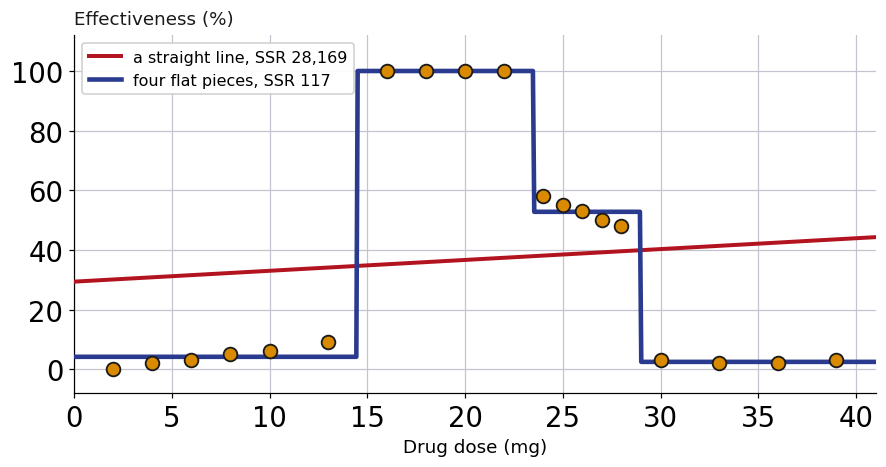

In [4]:
mlh.fig_line_vs_tree()

### You Could Do This With Dummies

- One dummy per piece: 1 if dose is under 14.5, 1 if it is at least 14.5 and under 23.5, 1 if it is at least 23.5 and under 29, 1 if it is 29 or more
- Regress effectiveness on those four, no intercept, and the coefficients come back <b style="color:#73000A;">4.2, 100, 52.8 and 2.5</b> with SSR <b style="color:#73000A;">117</b>
- Those four numbers are the tree's leaves, and the four conditions are its four paths
- So the model was never the hard part. Knowing where to cut is, and that is the only thing a tree does for you

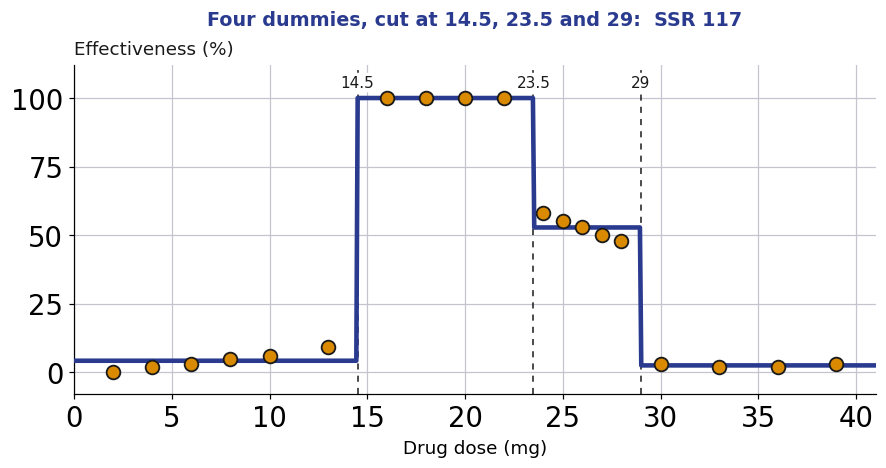

In [5]:
x, y = mlh._DT_DOSE, mlh._DT_EFF
g = np.linspace(0, 40.99, 600)
edges = [0, 14.5, 23.5, 29, 41]

def steps(ed):
    out = np.empty_like(g)
    for lo, hi in zip(ed[:-1], ed[1:]):
        m = (x >= lo) & (x < hi)
        out[(g >= lo) & (g < hi)] = y[m].mean() if m.any() else 0.0
    return out

fig, ax = plt.subplots(figsize=(8.4, 4.6), dpi=110)
fig.patch.set_facecolor("white"); ax.set_facecolor("white")
ax.grid(True, color=chh.GRID, lw=0.8, zorder=0); ax.set_axisbelow(True)
ax.plot(g, steps(edges), color=chh.MADRID, lw=3.0, zorder=4)
ax.scatter(x, y, s=80, color=chh.ACCENT, edgecolors=chh.INK, lw=1.2, zorder=6)
for cut in (14.5, 23.5, 29):
    ax.axvline(cut, color=chh.INK, lw=1.0, ls=(0, (4, 4)), zorder=2)
    ax.text(cut, 104, "%g" % cut, ha="center", fontsize=10, color=chh.INK,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none"))
ax.set_xlim(0, 41); ax.set_ylim(-8, 112)
ax.set_xlabel("Drug dose (mg)", fontsize=12)
ax.set_title("Four dummies, cut at 14.5, 23.5 and 29:  SSR 117",
             fontsize=12.5, color=chh.MADRID, weight="bold", pad=26)
ax.text(0, 1.02, "Effectiveness (%)", transform=ax.transAxes, ha="left",
        va="bottom", fontsize=12, color=chh.INK)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
fig.tight_layout()

In [6]:
from sklearn.tree import DecisionTreeRegressor

x, y = mlh._DT_DOSE, mlh._DT_EFF
cuts = [0, 14.5, 23.5, 29, 41]

def bins(edges):
    return np.column_stack([((x >= a) & (x < b)).astype(float)
                            for a, b in zip(edges[:-1], edges[1:])])

def fit(B):
    beta, *_ = np.linalg.lstsq(B, y, rcond=None)
    return beta, ((y - B @ beta) ** 2).sum()

print("%-36s %8s %9s" % ("what you regress on", "numbers", "SSR"))
print("%-36s %8s %9s" % ("-" * 34, "-" * 7, "-" * 7))
print("%-36s %8d %9.0f" % ("nothing, just the mean", 1, ((y - y.mean()) ** 2).sum()))
for label, deg in (("dose", 1), ("dose and its square", 2)):
    coef = np.polyfit(x, y, deg)
    print("%-36s %8d %9.0f"
          % (label, deg + 1, ((y - np.polyval(coef, x)) ** 2).sum()))
B = bins(cuts)
beta, ssr = fit(B)
print("%-36s %8d %9.0f" % ("4 dummies, cut at 14.5 / 23.5 / 29", 4, ssr))

tree = DecisionTreeRegressor(min_samples_split=7, random_state=0)
tree.fit(x.reshape(-1, 1), y)
print()
print("%-26s %9s %12s %11s" % ("dummy", "patients", "coefficient", "tree leaf"))
print("%-26s %9s %12s %11s" % ("-" * 24, "-" * 8, "-" * 11, "-" * 9))
for k, (a, b) in enumerate(zip(cuts[:-1], cuts[1:])):
    if k == 0:
        cond = "1 if dose < %g" % b
    elif b == cuts[-1]:
        cond = "1 if dose >= %g" % a
    else:
        cond = "1 if %g <= dose < %g" % (a, b)
    print("%-26s %9d %12.1f %11.1f"
          % (cond, B[:, k].sum(), beta[k], tree.predict([[(a + b) / 2]])[0]))

what you regress on                   numbers       SSR
----------------------------------    -------   -------
nothing, just the mean                      1     28456
dose                                        2     28169
dose and its square                         3     11885
4 dummies, cut at 14.5 / 23.5 / 29          4       117

dummy                       patients  coefficient   tree leaf
------------------------    --------  -----------   ---------
1 if dose < 14.5                   6          4.2         4.2
1 if 14.5 <= dose < 23.5           4        100.0       100.0
1 if 23.5 <= dose < 29             5         52.8        52.8
1 if dose >= 29                    4          2.5         2.5


In [7]:
# One place that knows how to draw a box-and-arrow tree. Every slide below
# supplies only its own boxes and arrows.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import course_helpers as chh

Q_FILL, LEAF_FILL = chh.ACCENT, "#2E8B57"
SHADE, LEAFLINE = "#D6E8F7", "#2E8B57"


def draw_tree(nodes, edges, title=None, figsize=(9.0, 4.3), fs=10.5, ax=None):
    """nodes: name -> (x, y, label, kind) with kind 'q' or 'leaf'.
       edges: (parent, child, label). Pass ax to draw into an existing panel."""
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=figsize, dpi=110)
        fig.patch.set_facecolor("white")
    ax.set_facecolor("white"); ax.axis("off")
    for a, b, lab in edges:
        x1, y1 = nodes[a][0], nodes[a][1]
        x2, y2 = nodes[b][0], nodes[b][1]
        ax.annotate("", xy=(x2, y2 + .30), xytext=(x1, y1 - .30),
                    arrowprops=dict(arrowstyle="-|>", color=chh.INK, lw=1.6))
        if lab:
            ax.text((x1 + x2) / 2 + (-.16 if x2 < x1 else .16), (y1 + y2) / 2,
                    lab, ha="center", va="center", fontsize=fs - 1.5,
                    color=chh.INK, zorder=8,
                    bbox=dict(boxstyle="round,pad=0.18", facecolor="white",
                              edgecolor="none"))
    def box_w(label):
        return max(1.35, 0.165 * max(len(t) for t in label.split("\n")) + 0.60)

    for name, (x, y, label, kind) in nodes.items():
        w = box_w(label)
        h = 0.30 + 0.24 * label.count("\n")
        ring = dict(edgecolor=chh.FITLINE, lw=2.6) if kind.endswith("*") else \
            dict(edgecolor=chh.INK, lw=1.3)
        ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                                    boxstyle="round,pad=0.10",
                                    facecolor=Q_FILL if kind[0] == "q" else LEAF_FILL,
                                    zorder=3, **ring))
        ax.text(x, y, label, ha="center", va="center", fontsize=fs,
                color="white", weight="bold", zorder=4)
    lo = [n[0] - box_w(n[2]) / 2 for n in nodes.values()]
    hi = [n[0] + box_w(n[2]) / 2 for n in nodes.values()]
    ys = [n[1] for n in nodes.values()]
    ax.set_xlim(min(lo) - 0.45, max(hi) + 0.45)
    ax.set_ylim(min(ys) - .7, max(ys) + (1.0 if title else .6))
    if title:
        ax.set_title(title, fontsize=12.5, color=chh.MADRID, weight="bold", pad=10)
    if own:
        fig.tight_layout(); plt.close(fig)
        return fig


# ---------------------------------------------------------------- the trial
DOSE, EFF = mlh._DT_DOSE, mlh._DT_EFF


def leaf_mean(lo, hi):
    m = (DOSE >= lo) & (DOSE < hi)
    return float(EFF[m].mean()), int(m.sum())


def dose_panel(ax, shade=(), leaves=(), stems=False, line=None, mark=None,
               title=None):
    """The data, with whichever node is being talked about shaded, its average
    drawn flat in green, and optionally a dotted stem from every point."""
    ax.set_facecolor("white")
    ax.grid(True, color=chh.GRID, lw=0.8, zorder=0); ax.set_axisbelow(True)
    for lo, hi in shade:
        ax.axvspan(lo, hi, color=SHADE, zorder=1)
    for lo, hi in leaves:
        v, _ = leaf_mean(lo, hi)
        if stems:
            m = (DOSE >= lo) & (DOSE < hi)
            ax.vlines(DOSE[m], v, EFF[m], color=chh.INK, lw=1.0, ls=(0, (2, 2)),
                      zorder=3)
        ax.plot([lo, hi], [v, v], lw=3.2, color=LEAFLINE, zorder=4)
    if line is not None:
        at = np.array([0, 41])
        ax.plot(at, line[0] + line[1] * at, lw=2.4, color=chh.FITLINE, zorder=4)
    ax.scatter(DOSE, EFF, s=58, color=chh.ACCENT, edgecolors=chh.INK, lw=1.0,
               zorder=5)
    if mark is not None:
        ax.scatter([mark[0]], [mark[1]], s=170, marker="X", color=chh.MADRID,
                   edgecolors=chh.INK, lw=1.0, zorder=7)
    ax.set_xlim(0, 41); ax.set_ylim(-8, 112)
    ax.set_xlabel("Drug dose (mg)", fontsize=11)
    ax.text(0, 1.02, "Effectiveness (%)", transform=ax.transAxes, ha="left",
            va="bottom", fontsize=11, color=chh.INK)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    if title:
        ax.set_title(title, fontsize=11.5, color=chh.MADRID, weight="bold", pad=24)


CUTS = (DOSE[:-1] + DOSE[1:]) / 2


def cut_ssr(t):
    lo, hi = EFF[DOSE < t], EFF[DOSE >= t]
    return float(((lo - lo.mean()) ** 2).sum() + ((hi - hi.mean()) ** 2).sum())


def ssr_panel(ax, upto, best=False, title=None):
    """His little scoreboard: every threshold scored so far, one dot each."""
    done = [t for t in CUTS if t <= upto]
    ax.set_facecolor("white")
    ax.grid(True, color=chh.GRID, lw=0.8, zorder=0); ax.set_axisbelow(True)
    ax.plot(done, [cut_ssr(t) for t in done], "o", ms=7, color=chh.FITLINE,
            zorder=4)
    if best:
        b = min(CUTS, key=cut_ssr)
        ax.scatter([b], [cut_ssr(b)], s=200, facecolors="none",
                   edgecolors=chh.MADRID, lw=2.4, zorder=5)
        ax.annotate("%.1f" % b, xy=(b, cut_ssr(b)), xytext=(b + 3, cut_ssr(b) - 3500),
                    fontsize=11, color=chh.MADRID,
                    arrowprops=dict(arrowstyle="-|>", color=chh.MADRID, lw=1.2))
    ax.set_xlim(0, 41); ax.set_ylim(0, 31000)
    ax.set_xlabel("threshold the tree would use", fontsize=11)
    ax.text(0, 1.02, "Sum of squared residuals", transform=ax.transAxes,
            ha="left", va="bottom", fontsize=11, color=chh.INK)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    if title:
        ax.set_title(title, fontsize=11.5, color=chh.MADRID, weight="bold", pad=24)


def pair(nodes, edges, width=(1.15, 1.0), **panel):
    """Data on the left, the tree as it stands on the right."""
    fig, (a, b) = plt.subplots(1, 2, figsize=(12.0, 4.5), dpi=110,
                               gridspec_kw=dict(width_ratios=list(width)))
    fig.patch.set_facecolor("white")
    dose_panel(a, **panel)
    draw_tree(nodes, edges, ax=b, fs=10.0)
    fig.tight_layout()
    plt.close(fig)
    return fig


TRUE_C, FALSE_C = "#2E8B57", "#8A8A93"


def html_table(head, rows, target=None, fs=19):
    """A data table sized for the projector. head: column titles. rows: tuples
       of values. target: index of the column being predicted, which gets the
       red header and a rule down its left edge. True and False are coloured so
       the pattern is readable from the back of the room."""
    from IPython.display import HTML

    def paint(v):
        v = str(v)
        if v == "True":
            return "<b style='color:%s;'>True</b>" % TRUE_C
        if v == "False":
            return "<span style='color:%s;'>False</span>" % FALSE_C
        # a value like "age < 9.5" would otherwise open a tag and eat the cell
        return (v.replace("&", "&amp;").replace("<", "&lt;")
                 .replace(">", "&gt;"))

    out = ["<table style='border-collapse:collapse;margin:8px auto;"
           "font-size:%dpx;line-height:1.35;'>" % fs, "<tr>"]
    for i, h in enumerate(head):
        out.append("<th style='border:none;padding:7px 18px;color:#FFFFFF;background:%s;"
                   "font-weight:600;text-align:center;white-space:nowrap;'>%s</th>"
                   % (chh.FITLINE if i == target else chh.MADRID,
                      str(h).replace("&", "&amp;").replace("<", "&lt;")
                            .replace(">", "&gt;")))
    out.append("</tr>")
    for r, row in enumerate(rows):
        out.append("<tr>")
        for i, v in enumerate(row):
            out.append("<td style='border:none;padding:6px 18px;text-align:center;"
                       "background:%s;%s'>%s</td>"
                       % ("#EEF1F8" if r % 2 else "#FFFFFF",
                          "border-left:2px solid %s;" % chh.FITLINE if i == target else "",
                          paint(v)))
        out.append("</tr>")
    out.append("</table>")
    return HTML("".join(out))


## A Tree States Something, Then Decides

A tree asks whether a statement is true, and sends you one way or the other.

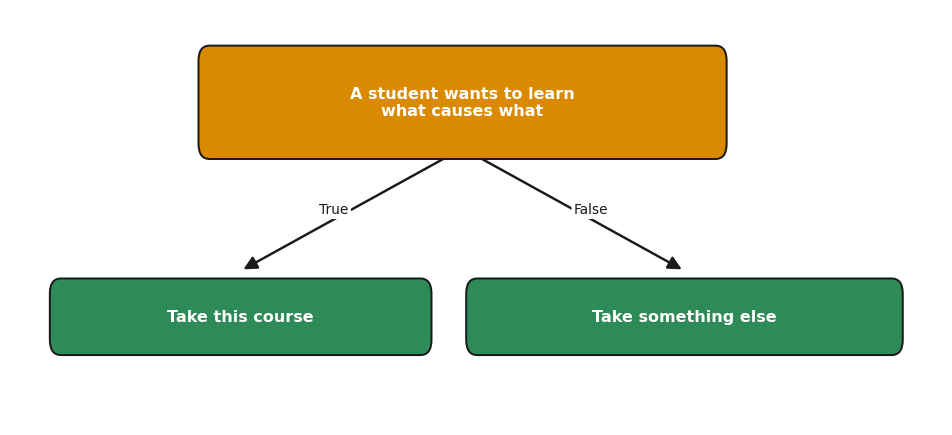

In [8]:
nodes = {
    "q":  (0.0, 2.0, "A student wants to learn\nwhat causes what", "q"),
    "l":  (-2.0, 0.6, "Take this course", "leaf"),
    "r":  (2.0, 0.6, "Take something else", "leaf"),
}
draw_tree(nodes, [("q", "l", "True"), ("q", "r", "False")])

## What a Tree Looks Like

- The top question is the <b style="color:#73000A;">root</b>
- A <b style="color:#73000A;">branch, or internal node</b> has arrows coming in and arrows going out
- A <b style="color:#73000A;">leaf</b> has arrows coming in and none going out
- To predict, start at the root and follow the answers down to a leaf
- True goes left, so the arrow labels are often left off altogether


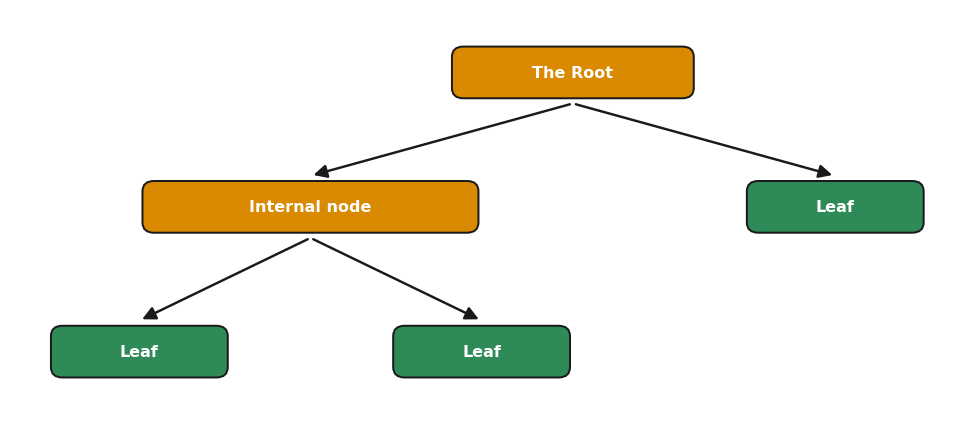

In [9]:
nodes = {
    "root": (0.0, 3.2, "The Root", "q"),
    "a":    (-2.3, 1.9, "Internal node", "q"),
    "b":    (2.3, 1.9, "Leaf", "leaf"),
    "a0":   (-3.8, 0.5, "Leaf", "leaf"),
    "a1":   (-0.8, 0.5, "Leaf", "leaf"),
}
edges = [("root", "a", ""), ("root", "b", ""), ("a", "a0", ""), ("a", "a1", "")]
draw_tree(nodes, edges, figsize=(9.2, 4.3))

### Categories or Numbers

- Leaves holding <b style="color:#73000A;">categories</b>: a classification tree
- Leaves holding <b style="color:#73000A;">numbers</b>: a regression tree
- Same machinery either way. Today is classification, and regression trees come later

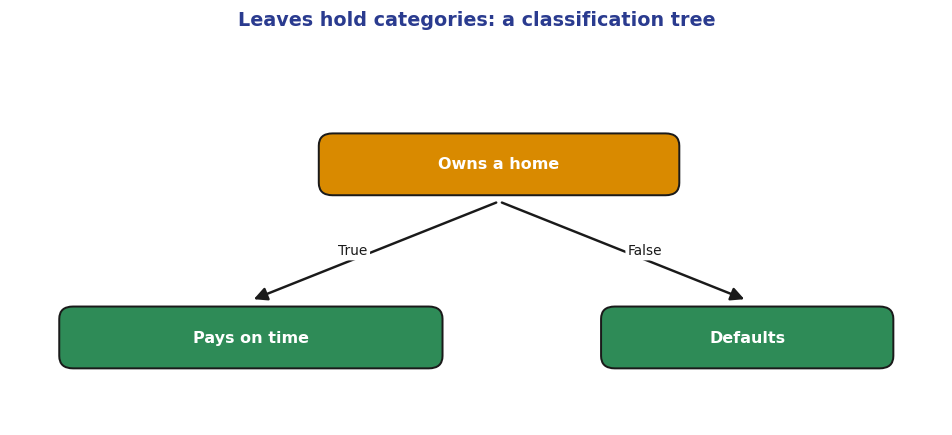

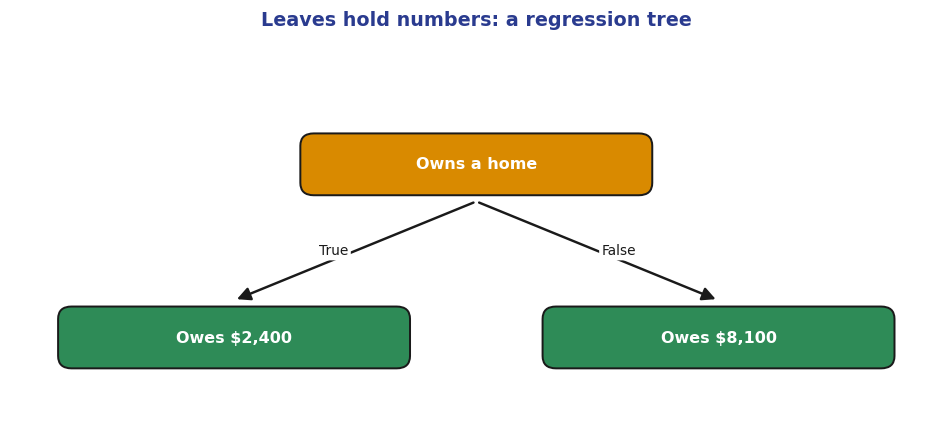

In [10]:
cls = {
    "q": (0.0, 2.0, "Owns a home", "q"),
    "l": (-1.8, 0.6, "Pays on time", "leaf"),
    "r": (1.8, 0.6, "Defaults", "leaf"),
}
reg = {
    "q": (0.0, 2.0, "Owns a home", "q"),
    "l": (-1.8, 0.6, "Owes $2,400", "leaf"),
    "r": (1.8, 0.6, "Owes $8,100", "leaf"),
}
display(draw_tree(cls, [("q", "l", "True"), ("q", "r", "False")],
                  title="Leaves hold categories: a classification tree"))
display(draw_tree(reg, [("q", "l", "True"), ("q", "r", "False")],
                  title="Leaves hold numbers: a regression tree"))

## A Bigger One

Three things to notice in this image:

- <b style="color:#73000A;">Data types can be mixed</b>: a true or false question at the top, numeric ones below it
- The <b style="color:#73000A;">same variable</b> appears twice, and the thresholds are <b style="color:#73000A;">not the same</b>
- <b style="color:#73000A;">The same answer</b> can show up in more than one leaf

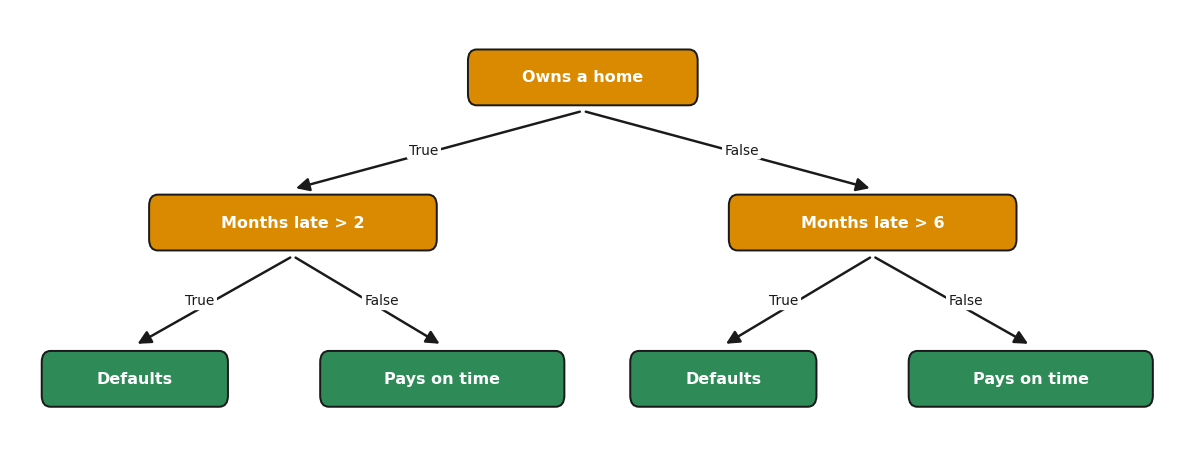

In [11]:
nodes = {
    "root": (0.0, 3.2, "Owns a home", "q"),
    "a":    (-3.3, 1.9, "Months late > 2", "q"),
    "b":    (3.3, 1.9, "Months late > 6", "q"),
    "a0":   (-5.1, 0.5, "Defaults", "leaf"),
    "a1":   (-1.6, 0.5, "Pays on time", "leaf"),
    "b0":   (1.6, 0.5, "Defaults", "leaf"),
    "b1":   (5.1, 0.5, "Pays on time", "leaf"),
}
edges = [("root", "a", "True"), ("root", "b", "False"),
         ("a", "a0", "True"), ("a", "a1", "False"),
         ("b", "b0", "True"), ("b", "b1", "False")]
draw_tree(nodes, edges, figsize=(11.2, 4.6))

### The Training Data

Seven people, three things we know about each of them, and the thing we want
to predict.


In [12]:
# The seven people. This is the whole training set.
person  = [1, 2, 3, 4, 5, 6, 7]
popcorn = ["True",  "True",  "False", "False", "True",  "True",  "False"]
soda    = ["True",  "False", "True",  "True",  "True",  "False", "False"]
age     = [7, 12, 18, 35, 38, 50, 83]
loves   = ["False", "False", "True",  "True",  "True",  "False", "False"]

head = ("person", "loves popcorn", "loves soda", "age", "loves Evil Dead 2")
display(html_table(head, list(zip(person, popcorn, soda, age, loves)), target=4))

person,loves popcorn,loves soda,age,loves Evil Dead 2
1,True,True,7,False
2,True,False,12,False
3,False,True,18,True
4,False,True,35,True
5,True,True,38,True
6,True,False,50,False
7,False,False,83,False


## Which Question Goes on Top?

Here is the tree those seven rows produce. How do we decide what goes at the top?

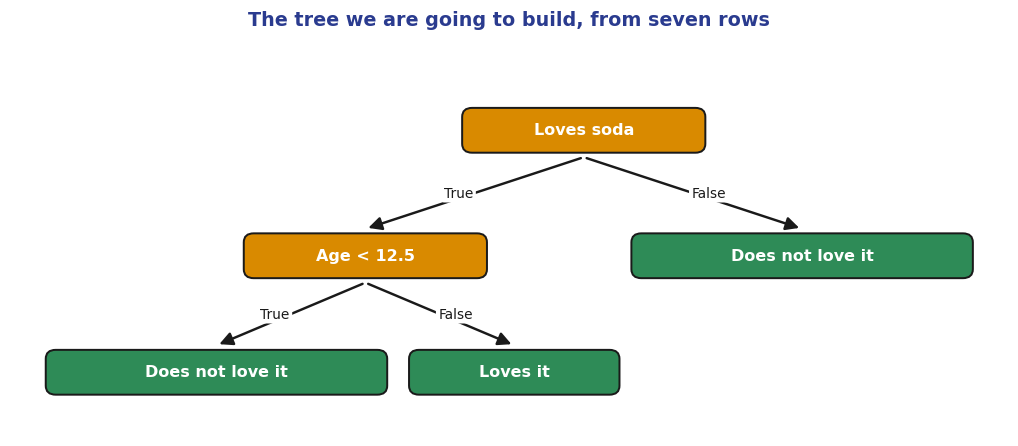

In [13]:
nodes = {
    "q":  (0.0, 3.0, "Loves soda", "q"),
    "a":  (-2.2, 1.6, "Age < 12.5", "q"),
    "r":  (2.2, 1.6, "Does not love it", "leaf"),
    "a0": (-3.7, 0.3, "Does not love it", "leaf"),
    "a1": (-0.7, 0.3, "Loves it", "leaf"),
}
edges = [("q", "a", "True"), ("q", "r", "False"),
         ("a", "a0", "True"), ("a", "a1", "False")]
draw_tree(nodes, edges, figsize=(9.6, 4.4),
          title="The tree we are going to build, from seven rows")

### Candidate 1: Loves Popcorn

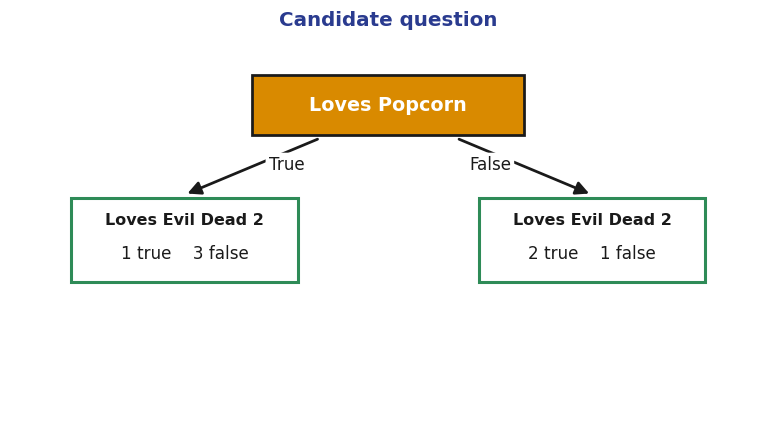

In [14]:
mlh.fig_dt_candidate('popcorn', show_gini=False)

### Count It Out, One Row at a Time

Before any formula: run the seven people down the popcorn tree and
<b style="color:#73000A;">keep a tally</b>.

- Someone who loves popcorn goes to the <b style="color:#73000A;">left</b> leaf
- Someone who does not goes to the <b style="color:#73000A;">right</b> leaf

In [15]:
left = {"True": 0, "False": 0}                    # loves popcorn
right = {"True": 0, "False": 0}                   # does not
print("%8s %10s %12s %20s" % ("person", "popcorn", "goes to", "loves Evil Dead 2"))
print("%8s %10s %12s %20s" % ("-" * 6, "-" * 8, "-" * 10, "-" * 18))
for i, (p, y) in enumerate(zip(popcorn, loves), start=1):
    side = "left leaf" if p == "True" else "right leaf"
    (left if p == "True" else right)[y] += 1
    print("%8d %10s %12s %20s" % (i, p, side, y))
print()
print("left leaf  (loves popcorn)      : %d love it, %d do not" % (left["True"], left["False"]))
print("right leaf (does not)           : %d love it, %d do not" % (right["True"], right["False"]))

  person    popcorn      goes to    loves Evil Dead 2
  ------   --------   ----------   ------------------
       1       True    left leaf                False
       2       True    left leaf                False
       3      False   right leaf                 True
       4      False   right leaf                 True
       5       True    left leaf                 True
       6       True    left leaf                False
       7      False   right leaf                False

left leaf  (loves popcorn)      : 1 love it, 3 do not
right leaf (does not)           : 2 love it, 1 do not


### Candidate 2: Loves Soda

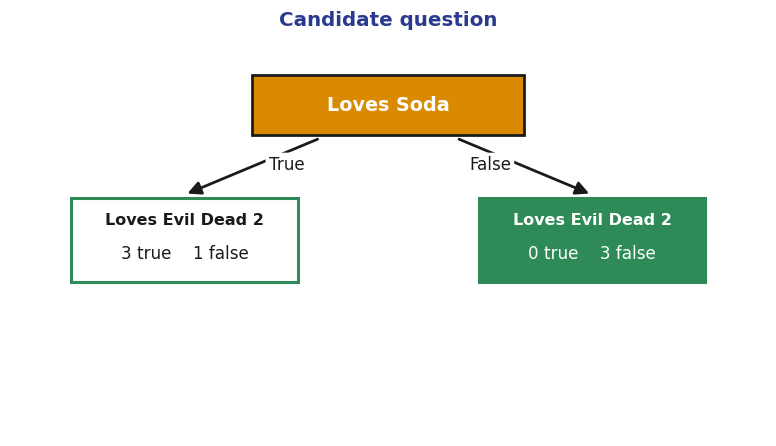

In [16]:
mlh.fig_dt_candidate('soda', show_gini=False)

### Neither One Is Perfect

- The popcorn tree leaves <b style="color:#73000A;">hold a mixture</b>, and so does one soda leaf
- One leaf is <b style="color:#73000A;">pure</b>: everyone who does not love soda also does not love the movie
- A leaf holding one kind of person is worth having. A leaf that is half and half
  tells you nothing
- So we need to <b style="color:#73000A;">put a number on how mixed a leaf is</b>

### Putting a Number on the Mixture

There are several ways to score impurity. <b style="color:#73000A;">Entropy</b> and
<b style="color:#73000A;">Information Gain</b> are two. We use <b style="color:#73000A;">Gini impurity</b>, which is
the most straightforward of them.

<div style="border-left: 5px solid #73000A; background-color: #F7F0F1;
            padding: 12px 18px; margin: 15px 0; border-radius: 0 6px 6px 0;">
<b style="color:#73000A;">Gini impurity:</b> Pull two people out of a leaf at random.
Gini is the chance they give you different answers.

$$\text{Gini} \;=\; 1 - \sum_i p_i^{2}$$
</div>

Then a split is scored by the <b style="color:#73000A;">average</b> of its leaves,
<b style="color:#73000A;">weighted by how many people are in each</b>.

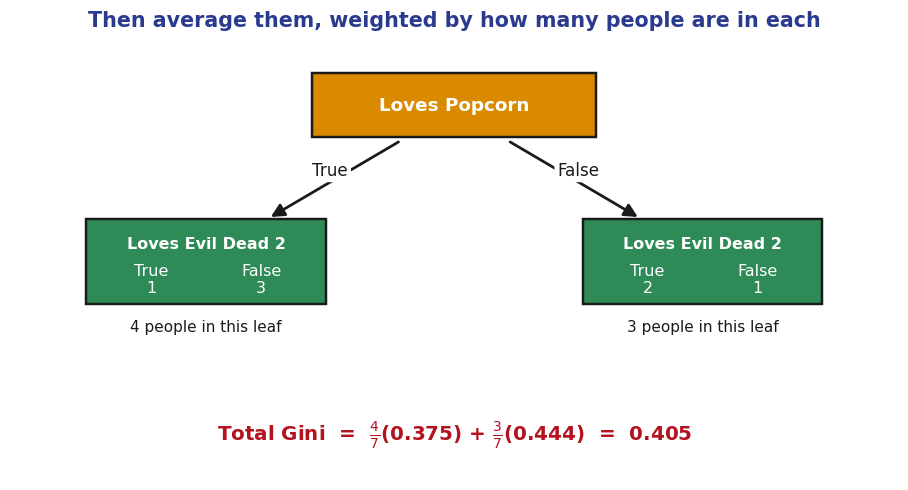

In [17]:
mlh.fig_gini_split(stage=1)

### Then Average the Two, Weighted by Size

Four people went left and three went right, so the left leaf counts for
<b style="color:#73000A;">4/7</b> of the score and the right for
<b style="color:#73000A;">3/7</b>.

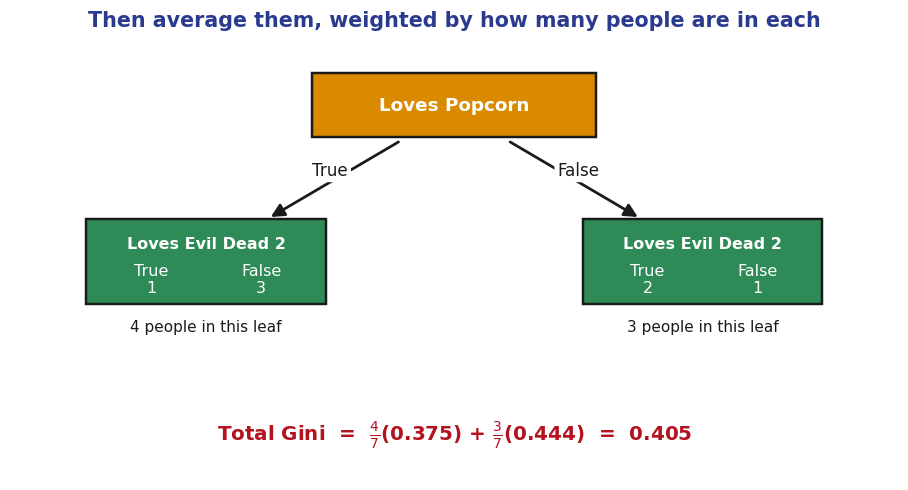

In [18]:
mlh.fig_gini_split(stage=2)

### The Same Arithmetic in Code

Two functions. <b style="color:#73000A;">gini</b> scores one leaf,
<b style="color:#73000A;">score</b> averages the leaves of a split. Every
question from here on is scored by these two.

In [19]:
def gini(n_true, n_false):
    n = n_true + n_false
    return 1 - (n_true / n) ** 2 - (n_false / n) ** 2

def score(rows):                                   # rows: (true, false) per leaf
    n = sum(y + q for y, q in rows)
    return sum((y + q) / n * gini(y, q) for y, q in rows)

left_g  = gini(left["True"], left["False"])
right_g = gini(right["True"], right["False"])
print("left leaf   1 - (%d/4)^2 - (%d/4)^2 = %.3f" % (left["True"], left["False"], left_g))
print("right leaf  1 - (%d/3)^2 - (%d/3)^2 = %.3f" % (right["True"], right["False"], right_g))
print()
print("weighted    4/7 x %.3f  +  3/7 x %.3f  =  %.3f"
      % (left_g, right_g, score([(left["True"], left["False"]), (right["True"], right["False"])])))
print()
print("that 0.405 is the popcorn question's score, and lower is better")

left leaf   1 - (1/4)^2 - (3/4)^2 = 0.375
right leaf  1 - (2/3)^2 - (1/3)^2 = 0.444

weighted    4/7 x 0.375  +  3/7 x 0.444  =  0.405

that 0.405 is the popcorn question's score, and lower is better


### And the Same Count for the Other Two Questions


- <b style="color:#73000A;">Loves soda</b>: the people who do not love soda are <b style="color:#73000A;">all the same</b>, so that leaf
  scores zero
- <b style="color:#73000A;">Age</b> is numeric, so every midpoint between two ages is its own candidate
  question, and each one gets scored the same way

### Candidate 3: Age Is Numeric

- Popcorn and soda each had <b style="color:#73000A;">one</b> question to ask. Age has as many as you care to invent
- Sort the seven people by age, lowest to highest

In [20]:
order = sorted(range(7), key=lambda k: age[k])
display(html_table(("person", "age", "loves Evil Dead 2"),
                   [(person[k], age[k], loves[k]) for k in order], target=2))

person,age,loves Evil Dead 2
1,7,False
2,12,False
3,18,True
4,35,True
5,38,True
6,50,False
7,83,False


### The Midpoint Between Each Adjacent Pair

Seven ages, six gaps between them, six questions worth asking.

In [21]:
cuts = [(a + b) / 2 for a, b in zip(sorted(age)[:-1], sorted(age)[1:])]

display(html_table(("the two ages", "midpoint", "the question"),
                   [("%d and %d" % (a, b), "%g" % c, "age < %g" % c)
                    for a, b, c in zip(sorted(age)[:-1], sorted(age)[1:], cuts)]))

the two ages,midpoint,the question
7 and 12,9.5,age < 9.5
12 and 18,15,age < 15
18 and 35,26.5,age < 26.5
35 and 38,36.5,age < 36.5
38 and 50,44,age < 44
50 and 83,66.5,age < 66.5


### Take the First One: age < 9.5

Only the seven year old sits below 9.5, so that leaf holds one person
and the other six go right.

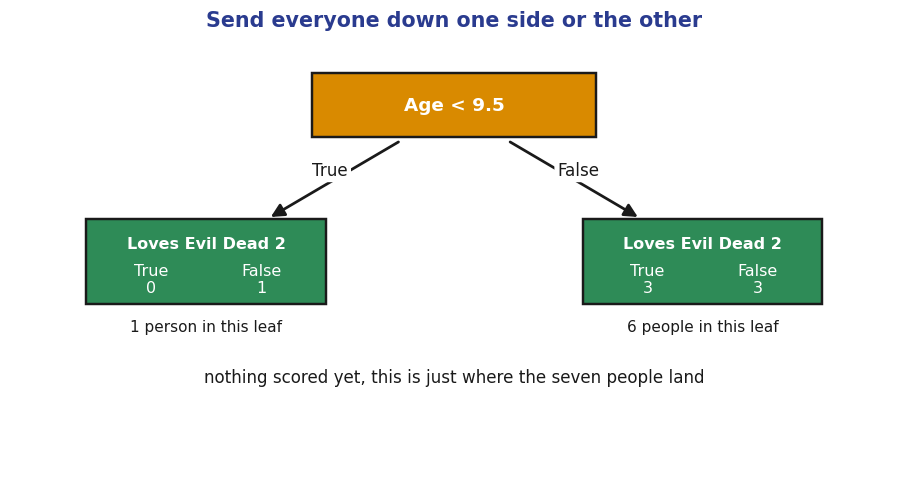

In [22]:
mlh.fig_gini_split(question="Age < 9.5", left=(0, 1), right=(3, 3),
                   stage="counts")

### The Left Leaf Is Settled

One person, one answer. There is nothing mixed about it, so it scores
<b style="color:#73000A;">0</b>.

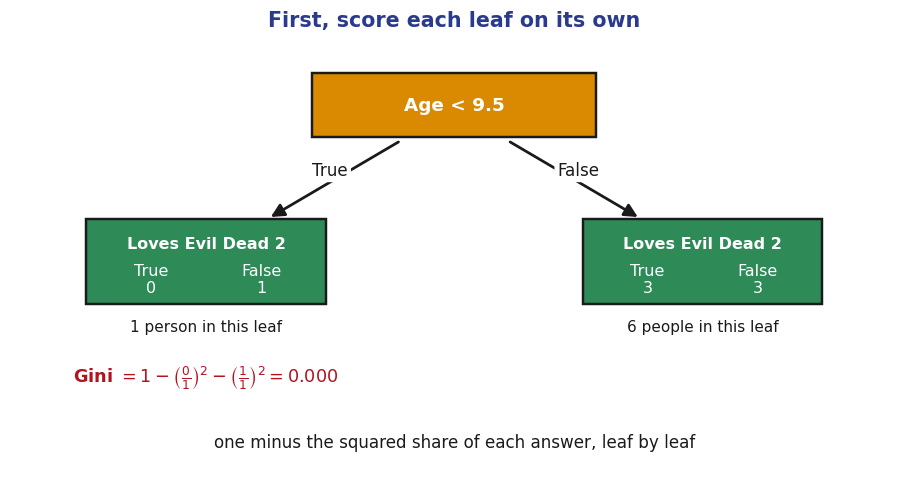

In [23]:
mlh.fig_gini_split(question="Age < 9.5", left=(0, 1), right=(3, 3),
                   stage="left")

### The Right Leaf Is As Mixed As It Gets

Three love it and three do not, which is the worst a two answer leaf can do.

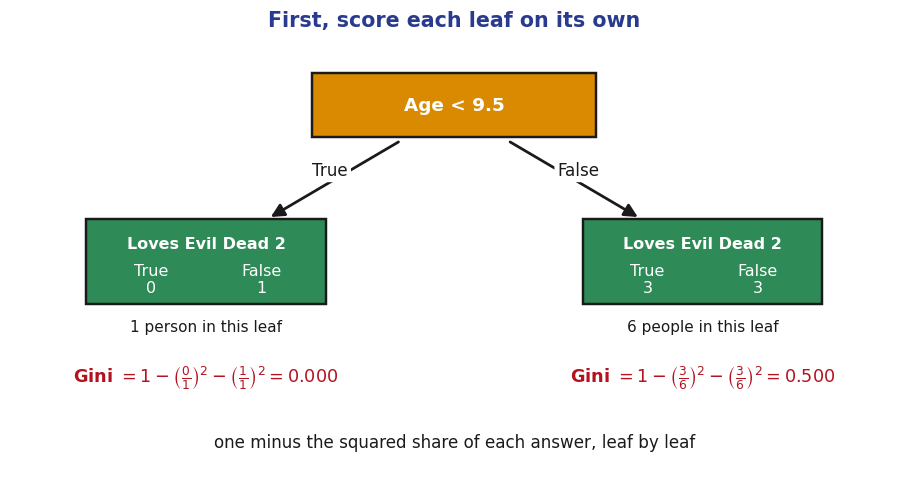

In [24]:
mlh.fig_gini_split(question="Age < 9.5", left=(0, 1), right=(3, 3),
                   stage="leaves")

### Weight Them by Size and Add

One person on the left, six on the right, so the right leaf carries
<b style="color:#73000A;">six sevenths</b> of the score.

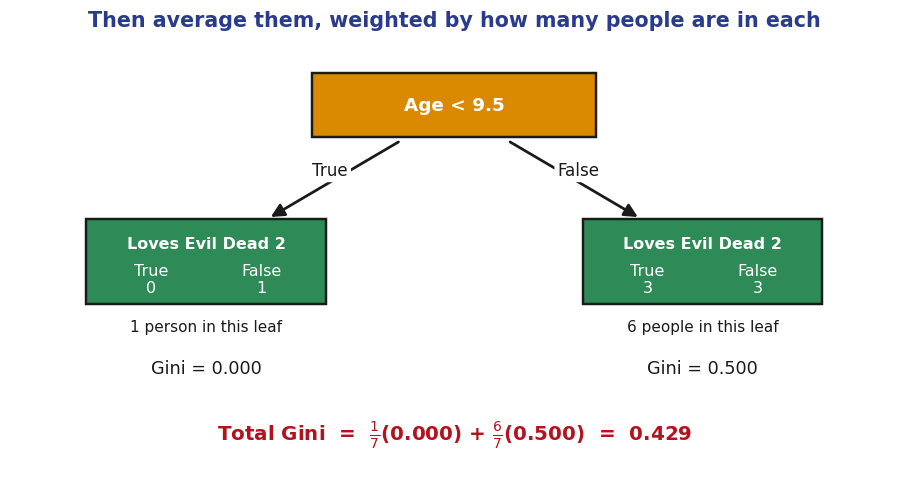

In [25]:
mlh.fig_gini_split(question="Age < 9.5", left=(0, 1), right=(3, 3),
                   stage="total")

### Now the Other Five

Same three steps, five more times.

In [26]:
def tally(feature, is_left):
    """Send each of the seven people left or right, and count the outcomes."""
    lf = {"True": 0, "False": 0}
    rt = {"True": 0, "False": 0}
    for value, y in zip(feature, loves):
        (lf if is_left(value) else rt)[y] += 1
    return [(lf["True"], lf["False"]), (rt["True"], rt["False"])]

rows = [tally(age, lambda v, c=c: v < c) for c in cuts]
scores = [score(r) for r in rows]

print("%-12s %16s %16s %8s" % ("question", "left leaf", "right leaf", "score"))
print("%-12s %16s %16s %8s" % ("-" * 10, "-" * 14, "-" * 14, "-" * 6))
for c, r, s in zip(cuts, rows, scores):
    print("%-12s %16s %16s %8.3f"
          % ("age < %g" % c, "%d true %d false" % r[0],
             "%d true %d false" % r[1], s))

question            left leaf       right leaf    score
----------     --------------   --------------   ------
age < 9.5      0 true 1 false   3 true 3 false    0.429
age < 15       0 true 2 false   3 true 2 false    0.343
age < 26.5     1 true 2 false   2 true 2 false    0.476
age < 36.5     2 true 2 false   1 true 2 false    0.476
age < 44       3 true 2 false   0 true 2 false    0.343
age < 66.5     3 true 3 false   0 true 1 false    0.429


### Weighted Gini Graphed


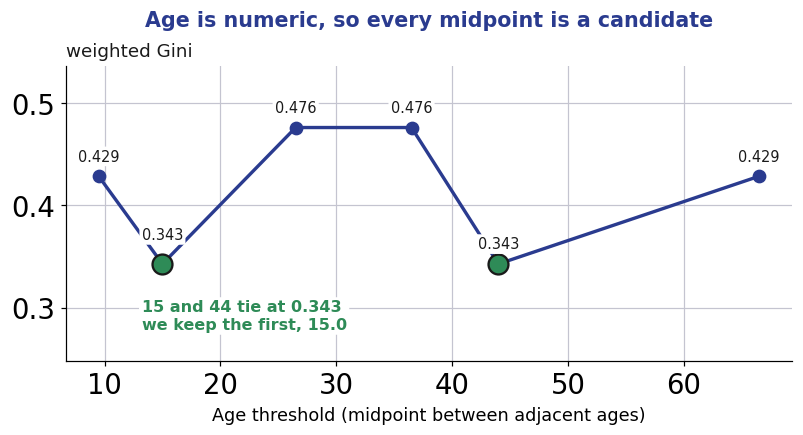

In [27]:
# cuts and scores came off the two slides before this one
best = int(np.argmin(scores))
tied = [k for k, v in enumerate(scores) if abs(v - scores[best]) < 1e-12]

PAD = dict(boxstyle="round,pad=0.16", facecolor="white", edgecolor="none")
fig, ax = plt.subplots(figsize=(7.8, 4.3), dpi=110)
fig.patch.set_facecolor("white"); ax.set_facecolor("white")
ax.grid(True, color=chh.GRID, lw=0.8, zorder=0); ax.set_axisbelow(True)
ax.plot(cuts, scores, "o-", color=chh.MADRID, lw=2.2, ms=8, zorder=3)
ax.scatter([cuts[k] for k in tied], [scores[k] for k in tied], s=170,
           color="#2E8B57", edgecolors=chh.INK, lw=1.5, zorder=5)
for k, (c, s) in enumerate(zip(cuts, scores)):
    ax.text(c, s + (0.024 if k == best else 0.015), "%.3f" % s, ha="center",
            fontsize=9.5, color=chh.INK, zorder=8, bbox=PAD)
ax.text(cuts[best] - 1.8, scores[best] - 0.035,
        "%s tie at %.3f\nwe keep the first, %.1f"
        % (" and ".join("%.0f" % cuts[k] for k in tied), scores[best],
           cuts[best]),
        ha="left", va="top", fontsize=10.5, color="#2E8B57", weight="bold",
        zorder=8, bbox=PAD)
ax.set_xlabel("Age threshold (midpoint between adjacent ages)", fontsize=11.5)
ax.text(0, 1.02, "weighted Gini", transform=ax.transAxes, ha="left",
        va="bottom", fontsize=12, color=chh.INK)
ax.set_ylim(min(scores) - 0.095, max(scores) + 0.06)
ax.set_title("Age is numeric, so every midpoint is a candidate",
             fontsize=13.5, color=chh.MADRID, weight="bold", pad=26)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
fig.tight_layout()

In [28]:
# tally and score come from the two slides before this one
print("%-16s %16s %16s %8s"
      % ("question", "left leaf", "right leaf", "score"))
print("%-16s %16s %16s %8s" % ("-" * 14, "-" * 14, "-" * 14, "-" * 6))
for label, rows in (("loves popcorn?", tally(popcorn, lambda v: v == "True")),
                    ("loves soda?", tally(soda, lambda v: v == "True"))):
    print("%-16s %16s %16s %8.3f"
          % (label, "%d true %d false" % rows[0],
             "%d true %d false" % rows[1], score(rows)))

best = int(np.argmin(scores))      # cuts and scores came off the last slide
rows = tally(age, lambda v: v <= cuts[best])
print("%-16s %16s %16s %8.3f"
      % ("age <= %.0f?" % cuts[best], "%d true %d false" % rows[0],
         "%d true %d false" % rows[1], scores[best]))
print()
tied = [cuts[k] for k, v in enumerate(scores) if abs(v - scores[best]) < 1e-12]
print("age %s tie at %.3f, so nothing picks between them and we keep the first"
      % (" and ".join("%.0f" % t for t in tied), scores[best]))
print("loves soda wins the root at 0.214, because one of its leaves is already pure")


question                left leaf       right leaf    score
--------------     --------------   --------------   ------
loves popcorn?     1 true 3 false   2 true 1 false    0.405
loves soda?        3 true 1 false   0 true 3 false    0.214
age <= 15?         0 true 2 false   3 true 2 false    0.343

age 15 and 44 tie at 0.343, so nothing picks between them and we keep the first
loves soda wins the root at 0.214, because one of its leaves is already pure


### The Scoreboard

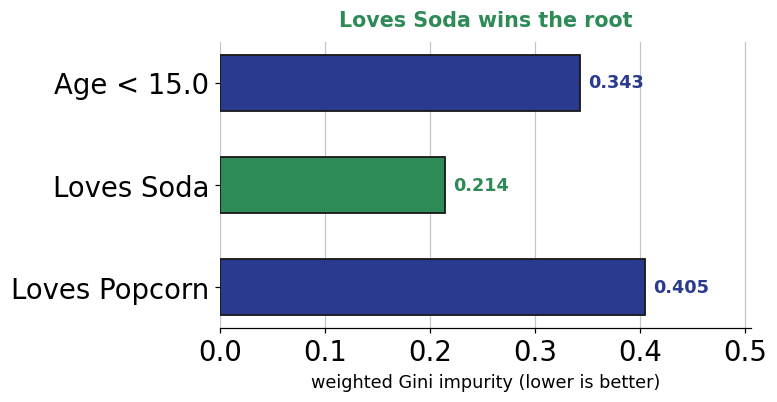

In [29]:
mlh.fig_dt_scoreboard()

In [30]:
import itertools

def gini(n_true, n_false):
    n = n_true + n_false
    return 1 - (n_true / n) ** 2 - (n_false / n) ** 2

print("%-16s %9s %22s" % ("leaf", "formula", "all pairs of draws"))
print("%-16s %9s %22s" % ("-" * 14, "-" * 7, "-" * 18))
for n_true, n_false in ((1, 3), (2, 1), (4, 0), (2, 2)):
    labels = [1] * n_true + [0] * n_false
    disagree = np.mean([u != v for u, v in itertools.product(labels, labels)])
    print("%-16s %9.3f %22.3f"
          % ("%d true %d false" % (n_true, n_false),
             gini(n_true, n_false), disagree))

leaf               formula     all pairs of draws
--------------     -------     ------------------
1 true 3 false       0.375                  0.375
2 true 1 false       0.444                  0.444
4 true 0 false       0.000                  0.000
2 true 2 false       0.500                  0.500


### Entropy: Another Way to Measure a Mixed Group

$$\text{Entropy} \;=\; -\sum_i p_i \log_2 p_i$$

- A group that is half true and half false still owes you an answer, and scores <b style="color:#73000A;">1</b>
- A group where everyone matches owes you nothing, and scores <b style="color:#73000A;">0</b>
- With two outcomes entropy runs 0 to 1, and Gini measures the same idea on a scale of 0 to 0.5
- Ranking splits by entropy ranks them by how likely the observed outcomes are, which is what lowering <b style="color:#73000A;">deviance</b> means

In [31]:
def entropy(counts, base=2):
    c = np.asarray(counts, float)
    q = c[c > 0] / c.sum()
    return float(-(q * np.log(q) / np.log(base)).sum())

leaves = [np.array([1, 3]), np.array([3, 0])]      # soda true leaf, soda false leaf
n = 7
weighted = sum(c.sum() / n * entropy(c, base=np.e) for c in leaves)
loglik = sum((c[c > 0] * np.log(c[c > 0] / c.sum())).sum() for c in leaves)

print("weighted entropy of the soda split, using ln  %8.4f" % weighted)
print("log likelihood of those same two leaves       %8.4f" % loglik)
print("minus n times the weighted entropy            %8.4f" % (-n * weighted))

weighted entropy of the soda split, using ln    0.3213
log likelihood of those same two leaves        -2.2493
minus n times the weighted entropy             -2.2493


### The Two Scores Rank Splits the Same Way

- Every candidate question from the seven people comes out in the <b style="color:#73000A;">same order</b> under both
- Double the Gini curve and the two never sit more than <b style="color:#73000A;">0.109</b> apart
- scikit-learn builds the identical tree on this data whichever one you ask for

In [32]:
p = np.array([v == "True" for v in popcorn])       # the seven people again
s = np.array([v == "True" for v in soda])
a = np.asarray(age)
y = np.array([v == "True" for v in loves], dtype=int)

def score(left, f):
    return ((left.sum() / 7) * f(np.bincount(y[left], minlength=2))
            + ((7 - left.sum()) / 7) * f(np.bincount(y[~left], minlength=2)))

def gini_counts(c):
    return gini(c[1], c[0]) if c.sum() else 0.0

cands = [("loves popcorn", p == 1), ("loves soda", s == 1)]
cands += [("age < %.1f" % t, a < t) for t in (a[:-1] + a[1:]) / 2]

print("%-16s %10s %10s" % ("candidate", "gini", "entropy"))
print("%-16s %10s %10s" % ("-" * 14, "-" * 8, "-" * 8))
for name, m in cands:
    print("%-16s %10.3f %10.3f" % (name, score(m, gini_counts), score(m, entropy)))

candidate              gini    entropy
--------------     --------   --------
loves popcorn         0.405      0.857
loves soda            0.214      0.464
age < 9.5             0.429      0.857
age < 15.0            0.343      0.694
age < 26.5            0.476      0.965
age < 36.5            0.476      0.965
age < 44.0            0.343      0.694
age < 66.5            0.429      0.857


### Which Split Criterion Should We Use?

- **Gini Impurity is the Default:** Fast, simple, and gives almost identical results to Entropy in practice.

- **They Want the Same Thing (Pure Groups):**
  Think of splitting data like sorting a mixed bowl of Red and Blue candies into two separate bowls:
  * **Gini (The Pragmatist):** Cares about getting groups mostly unmixed.
  * **Entropy (The Perfectionist):** Cares about getting groups *completely* unmixed. It gets extra strict when trying to clean up that very last rogue candy.
  * **In Practice:** This minor difference in strictness almost never changes your real-world business conclusions.

- **Choice Rarely Changes Results:** If switching between Gini and Entropy completely changes your model's decisions, your tree is likely overcomplicated or unstable.

- **For Replication:** Pick one, state it clearly in your methodology, and stick with it.

## Regression Trees: Predicting a Number

- A classification tree puts a <b style="color:#73000A;">category</b> in each leaf. A regression tree puts a <b style="color:#73000A;">number</b>
- That number is the <b style="color:#73000A;">average</b> of the training patients who land in the leaf
- Same search as before, scored by <b style="color:#73000A;">SSR</b> instead of Gini

### When a Straight Line Would Do

- If effectiveness just climbed with dose, a line answers the question
- Ask about a 27 mg dose and you read <b style="color:#73000A;">62%</b> straight off it

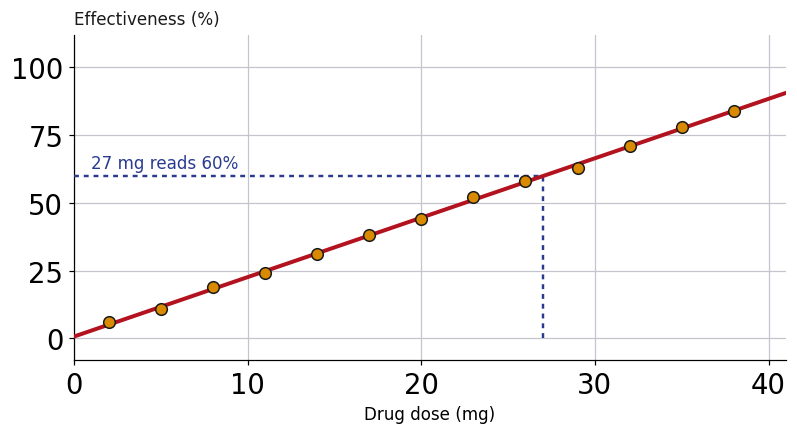

In [33]:
rise_dose = np.array([2., 5., 8., 11., 14., 17., 20., 23., 26., 29., 32., 35., 38.])
rise_eff = np.array([6., 11., 19., 24., 31., 38., 44., 52., 58., 63., 71., 78., 84.])
m1, m0 = np.polyfit(rise_dose, rise_eff, 1)

fig, ax = plt.subplots(figsize=(7.6, 4.3), dpi=110)
fig.patch.set_facecolor("white"); ax.set_facecolor("white")
ax.grid(True, color=chh.GRID, lw=0.8, zorder=0); ax.set_axisbelow(True)
at = np.array([0, 41])
ax.plot(at, m0 + m1 * at, lw=2.6, color=chh.FITLINE, zorder=4)
ax.scatter(rise_dose, rise_eff, s=58, color=chh.ACCENT, edgecolors=chh.INK,
           lw=1.0, zorder=5)
ax.plot([27, 27], [0, m0 + m1 * 27], lw=1.6, ls=(0, (2, 2)), color=chh.MADRID,
        zorder=3)
ax.plot([0, 27], [m0 + m1 * 27] * 2, lw=1.6, ls=(0, (2, 2)), color=chh.MADRID,
        zorder=3)
ax.text(1, m0 + m1 * 27 + 3, "27 mg reads %.0f%%" % (m0 + m1 * 27), fontsize=11,
        color=chh.MADRID)
ax.set_xlim(0, 41); ax.set_ylim(-8, 112)
ax.set_xlabel("Drug dose (mg)", fontsize=11)
ax.text(0, 1.02, "Effectiveness (%)", transform=ax.transAxes, ha="left",
        va="bottom", fontsize=11, color=chh.INK)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
fig.tight_layout()

### And When It Will Not

- Low doses do nothing, the middle works, high doses do nothing again
- The same line through these nineteen patients reads <b style="color:#73000A;">36.7%</b> at 20 mg
- The patient on 20 mg came in at <b style="color:#73000A;">100%</b>

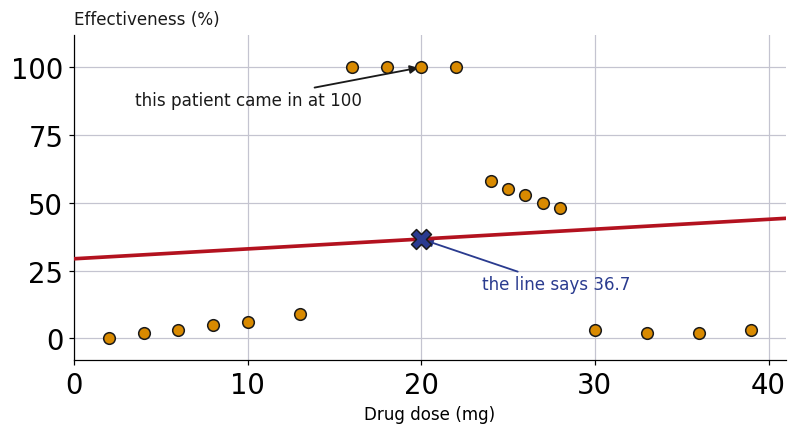

In [34]:
b1, b0 = np.polyfit(DOSE, EFF, 1)

fig, ax = plt.subplots(figsize=(7.6, 4.3), dpi=110)
fig.patch.set_facecolor("white")
dose_panel(ax, line=(b0, b1), mark=(20, b0 + b1 * 20))
ax.annotate("the line says %.1f" % (b0 + b1 * 20), xy=(20, b0 + b1 * 20),
            xytext=(23.5, 18), fontsize=11, color=chh.MADRID,
            arrowprops=dict(arrowstyle="-|>", color=chh.MADRID, lw=1.2))
ax.annotate("this patient came in at 100", xy=(20, 100), xytext=(3.5, 86),
            fontsize=11, color=chh.INK,
            arrowprops=dict(arrowstyle="-|>", color=chh.INK, lw=1.2))
fig.tight_layout()

## The Tree We Are Aiming At

- Three questions, four leaves, and every leaf holds an average effectiveness
- Start at the top, answer, and keep going until you run out of questions
- The next four slides take one leaf each and show whose average it is

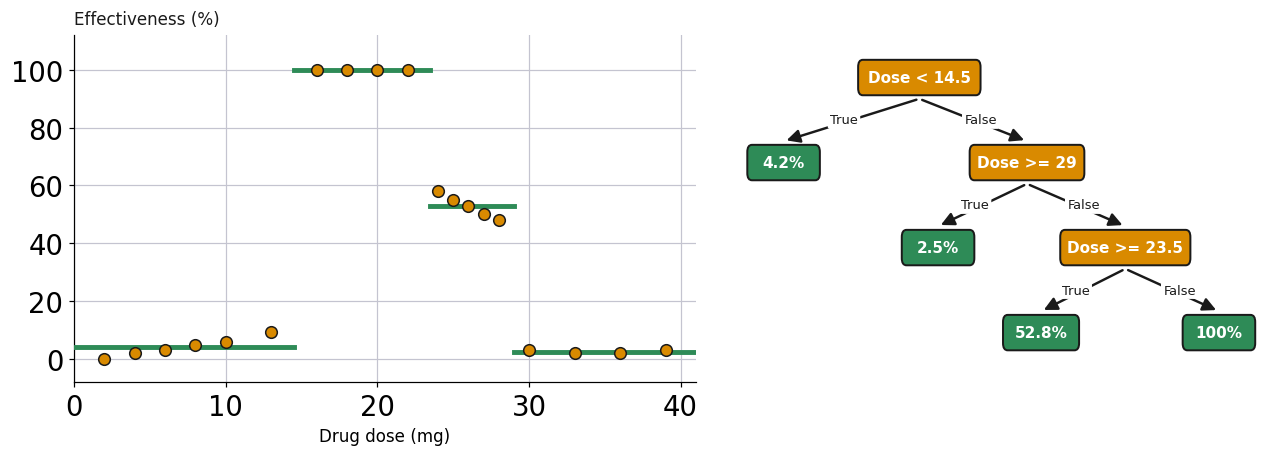

In [35]:
nodes = {
    "root": (0.0, 3.6, "Dose < 14.5", "q"),
    "l":    (-2.9, 2.4, "4.2%", "leaf"),
    "r":    (2.3, 2.4, "Dose >= 29", "q"),
    "rl":   (0.4, 1.2, "2.5%", "leaf"),
    "rr":   (4.4, 1.2, "Dose >= 23.5", "q"),
    "rrl":  (2.6, 0.0, "52.8%", "leaf"),
    "rrr":  (6.4, 0.0, "100%", "leaf"),
}
edges = [("root", "l", "True"), ("root", "r", "False"),
         ("r", "rl", "True"), ("r", "rr", "False"),
         ("rr", "rrl", "True"), ("rr", "rrr", "False")]

display(pair(nodes, edges, leaves=[(0, 14.5), (14.5, 23.5), (23.5, 29), (29, 41)]))

### Dose < 14.5

- The drug is doing nothing for these 6 patients
- Their average effectiveness is <b style="color:#73000A;">4.2%</b>
- So the leaf predicts 4.2% for anyone who answers their way down to it

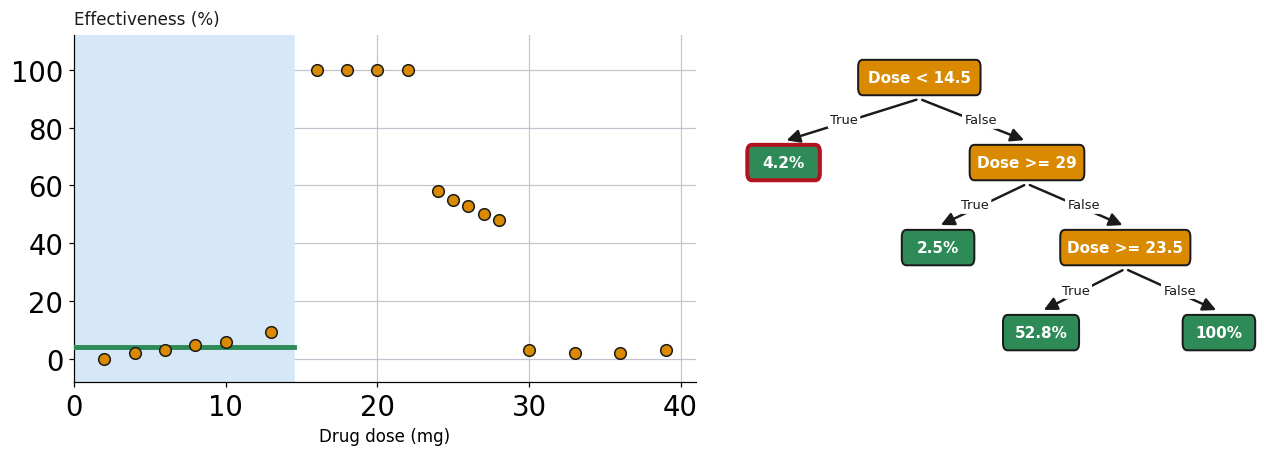

In [36]:
nodes = {
    "root": (0.0, 3.6, "Dose < 14.5", "q"),
    "l":    (-2.9, 2.4, "4.2%", "leaf*"),
    "r":    (2.3, 2.4, "Dose >= 29", "q"),
    "rl":   (0.4, 1.2, "2.5%", "leaf"),
    "rr":   (4.4, 1.2, "Dose >= 23.5", "q"),
    "rrl":  (2.6, 0.0, "52.8%", "leaf"),
    "rrr":  (6.4, 0.0, "100%", "leaf"),
}
edges = [("root", "l", "True"), ("root", "r", "False"),
         ("r", "rl", "True"), ("r", "rr", "False"),
         ("rr", "rrl", "True"), ("rr", "rrr", "False")]

display(pair(nodes, edges, shade=[(0, 14.5)], leaves=[(0, 14.5)]))

### Dose >= 29

- the four highest, and it has stopped working again
- 4 patients land here, and their average effectiveness is <b style="color:#73000A;">2.5%</b>
- So the leaf predicts 2.5% for anyone who answers their way down to it

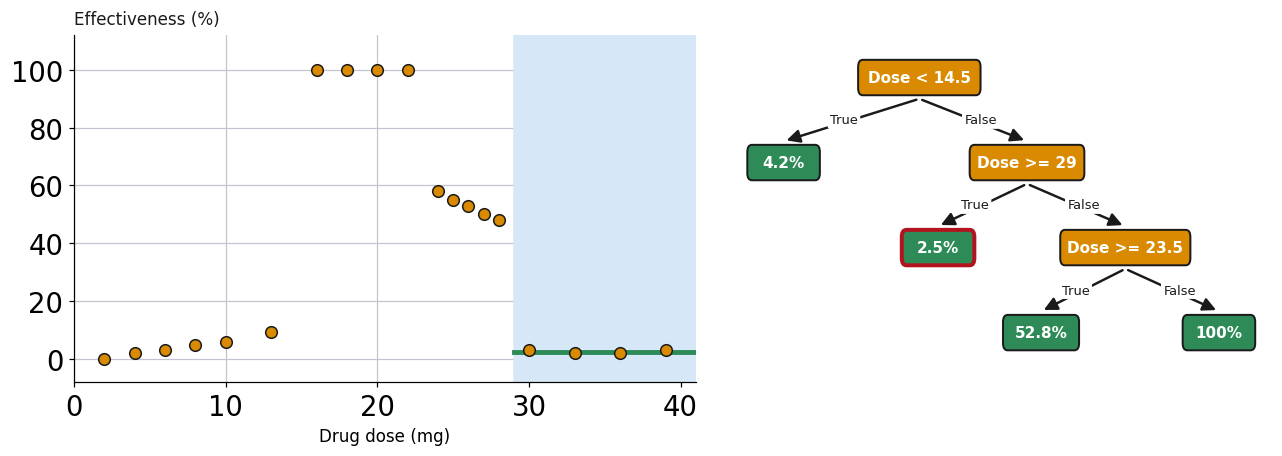

In [37]:
nodes = {
    "root": (0.0, 3.6, "Dose < 14.5", "q"),
    "l":    (-2.9, 2.4, "4.2%", "leaf"),
    "r":    (2.3, 2.4, "Dose >= 29", "q"),
    "rl":   (0.4, 1.2, "2.5%", "leaf*"),
    "rr":   (4.4, 1.2, "Dose >= 23.5", "q"),
    "rrl":  (2.6, 0.0, "52.8%", "leaf"),
    "rrr":  (6.4, 0.0, "100%", "leaf"),
}
edges = [("root", "l", "True"), ("root", "r", "False"),
         ("r", "rl", "True"), ("r", "rr", "False"),
         ("rr", "rrl", "True"), ("rr", "rrr", "False")]

display(pair(nodes, edges, shade=[(29, 41)], leaves=[(29, 41)]))

### Between 23.5 and 29

- five patients, about half as good as the best
- 5 patients land here, and their average effectiveness is <b style="color:#73000A;">52.8%</b>
- So the leaf predicts 52.8% for anyone who answers their way down to it

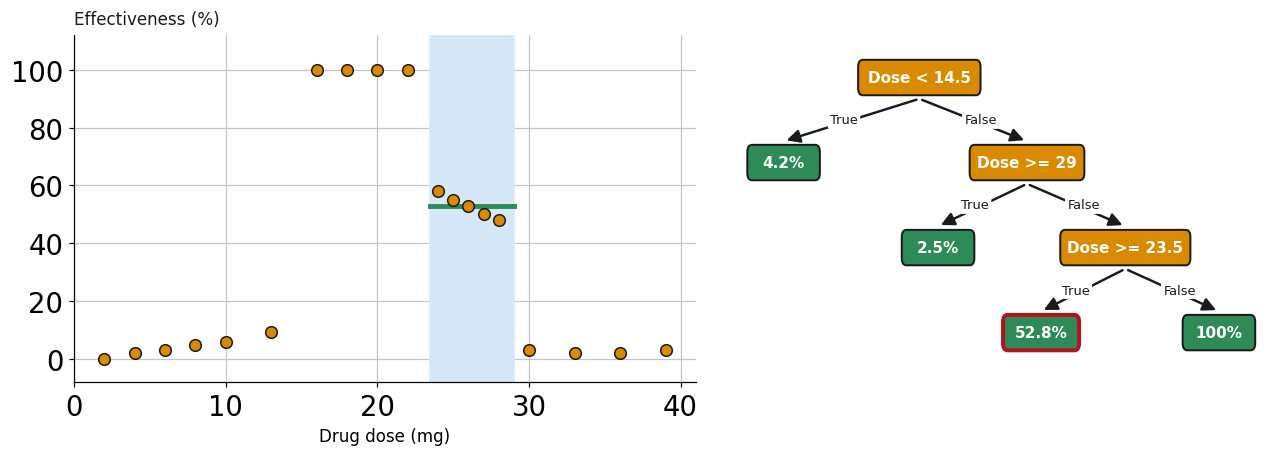

In [38]:
nodes = {
    "root": (0.0, 3.6, "Dose < 14.5", "q"),
    "l":    (-2.9, 2.4, "4.2%", "leaf"),
    "r":    (2.3, 2.4, "Dose >= 29", "q"),
    "rl":   (0.4, 1.2, "2.5%", "leaf"),
    "rr":   (4.4, 1.2, "Dose >= 23.5", "q"),
    "rrl":  (2.6, 0.0, "52.8%", "leaf*"),
    "rrr":  (6.4, 0.0, "100%", "leaf"),
}
edges = [("root", "l", "True"), ("root", "r", "False"),
         ("r", "rl", "True"), ("r", "rr", "False"),
         ("rr", "rrl", "True"), ("rr", "rrr", "False")]

display(pair(nodes, edges, shade=[(23.5, 29)], leaves=[(23.5, 29)]))

### Between 14.5 and 23.5

- the four the drug actually works on
- 4 patients land here, and their average effectiveness is <b style="color:#73000A;">100%</b>
- So the leaf predicts 100% for anyone who answers their way down to it

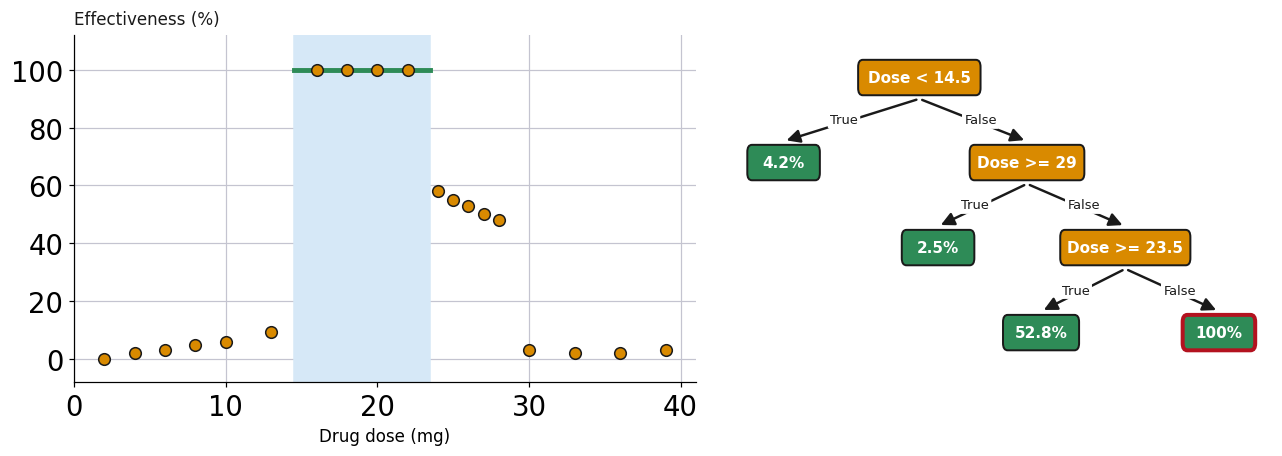

In [39]:
nodes = {
    "root": (0.0, 3.6, "Dose < 14.5", "q"),
    "l":    (-2.9, 2.4, "4.2%", "leaf"),
    "r":    (2.3, 2.4, "Dose >= 29", "q"),
    "rl":   (0.4, 1.2, "2.5%", "leaf"),
    "rr":   (4.4, 1.2, "Dose >= 23.5", "q"),
    "rrl":  (2.6, 0.0, "52.8%", "leaf"),
    "rrr":  (6.4, 0.0, "100%", "leaf*"),
}
edges = [("root", "l", "True"), ("root", "r", "False"),
         ("r", "rl", "True"), ("r", "rr", "False"),
         ("rr", "rrl", "True"), ("rr", "rrr", "False")]

display(pair(nodes, edges, shade=[(14.5, 23.5)], leaves=[(14.5, 23.5)]))

## Building It From the Top

- The 14.5 threshold came out of a search
- Take the two smallest doses, 2 and 4, and try the midpoint: <b style="color:#73000A;">dose < 3</b>
- One patient goes left and the other eighteen go right, each leaf predicting its own average

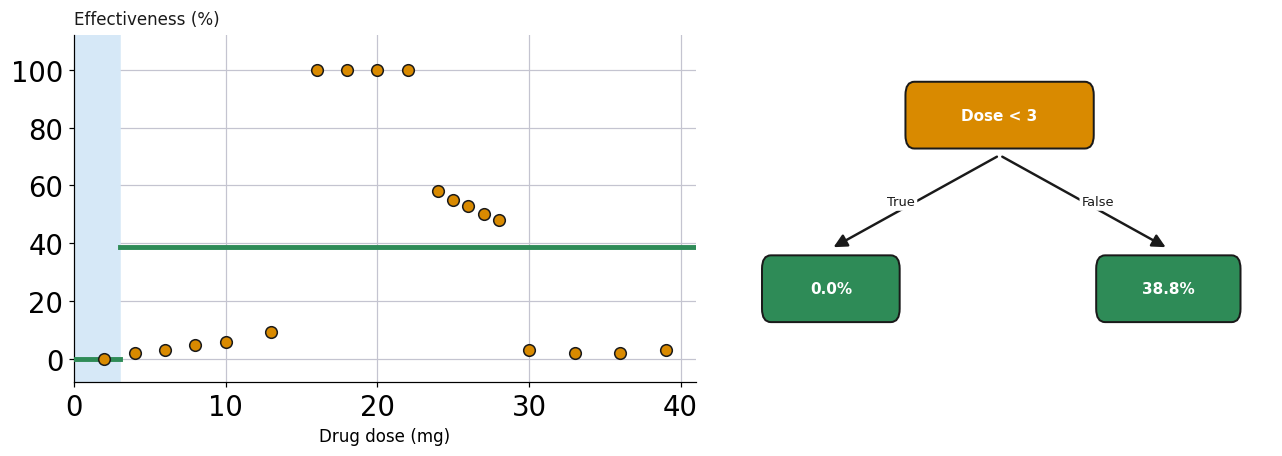

In [40]:
nodes = {
    "root": (0.0, 2.2, "Dose < 3", "q"),
    "l":    (-1.9, 0.9, "0.0%", "leaf"),
    "r":    (1.9, 0.9, "38.8%", "leaf"),
}
edges = [("root", "l", "True"), ("root", "r", "False")]
display(pair(nodes, edges, shade=[(0, 3)], leaves=[(0, 3), (3, 41)]))

### Every Residual, Squared, Added Up

- Drop a dotted line from each patient to their leaf's green line
- Square each one and add them: <b style="color:#73000A;">27,027</b>
- One number, for one candidate threshold

SSR = (0.0 - 0.0)^2 + (2.0 - 38.8)^2 + (3.0 - 38.8)^2 + (5.0 - 38.8)^2 + ...
    = 27026.6


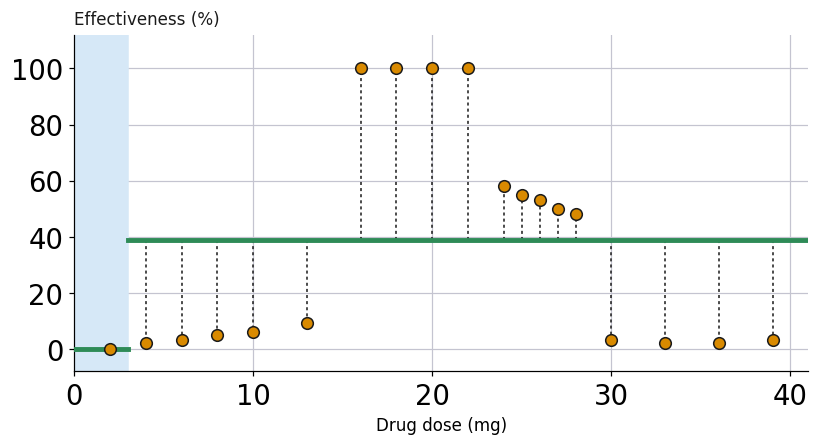

In [41]:
fig, ax = plt.subplots(figsize=(7.8, 4.4), dpi=110)
fig.patch.set_facecolor("white")
dose_panel(ax, shade=[(0, 3)], leaves=[(0, 3), (3, 41)], stems=True)
fig.tight_layout()

left, right = EFF[DOSE < 3], EFF[DOSE >= 3]
terms = ["(%.1f - %.1f)^2" % (v, left.mean()) for v in left]
terms += ["(%.1f - %.1f)^2" % (v, right.mean()) for v in right[:3]]
print("SSR = " + " + ".join(terms) + " + ...")
print("    = %.1f" % cut_ssr(3.0))

### Plot the Score Against the Threshold

- One dot: the threshold on the bottom, the score up the side
- Move the cut to the midpoint of the next pair, 5, and score it again
- The score falls, so 5 makes better predictions than 3 did

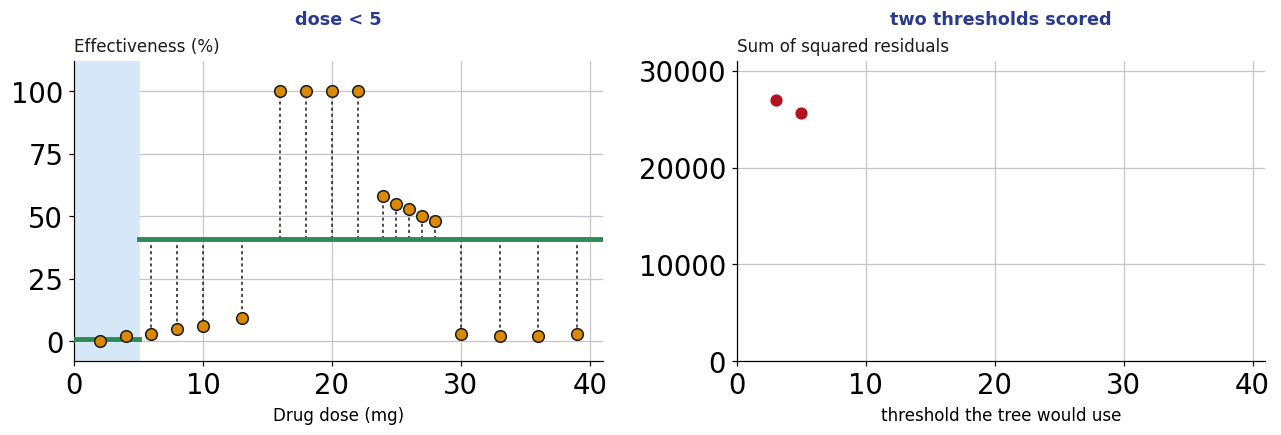

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.3), dpi=110)
fig.patch.set_facecolor("white")
dose_panel(axes[0], shade=[(0, 5)], leaves=[(0, 5), (5, 41)], stems=True,
           title="dose < 5")
ssr_panel(axes[1], upto=5.0, title="two thresholds scored")
fig.tight_layout()

### All Eighteen Thresholds

- Nineteen patients give eighteen midpoints, and each one is one dot
- The curve dips, bottoms out, and climbs again
- <b style="color:#73000A;">14.5</b> has the smallest score, <b style="color:#73000A;">19,137</b>, so that question becomes the root

best threshold 14.5 with SSR 19136.5


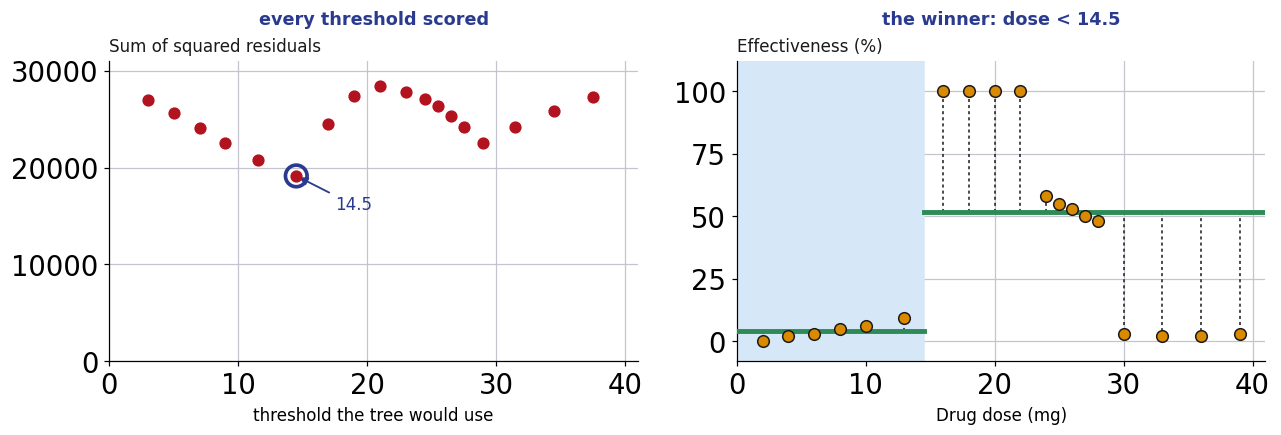

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.3), dpi=110)
fig.patch.set_facecolor("white")
ssr_panel(axes[0], upto=41, best=True, title="every threshold scored")
dose_panel(axes[1], shade=[(0, 14.5)], leaves=[(0, 14.5), (14.5, 41)],
           stems=True, title="the winner: dose < 14.5")
fig.tight_layout()
print("best threshold %.1f with SSR %.1f" % (min(CUTS, key=cut_ssr),
                                             cut_ssr(min(CUTS, key=cut_ssr))))

## Then Do It Again, Inside Each Group

- The six patients below 14.5 get the same treatment, their own search over their own midpoints
- It keeps going until every one of them sits alone in a leaf
- Six patients, <b style="color:#73000A;">six leaves</b>, and the tree now reproduces all six values

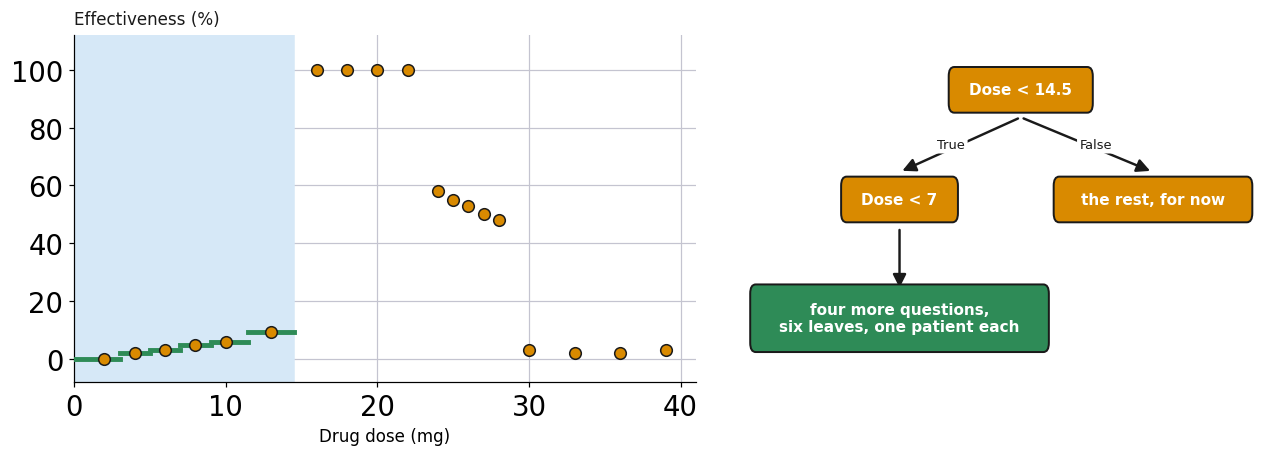

6 leaves for 6 patients
predicted [0.  2.  3.  5.  6.  9.2]
observed  [0.  2.  3.  5.  6.  9.2]


In [44]:
singles = [(0, 3), (3, 5), (5, 7), (7, 9), (9, 11.5), (11.5, 14.5)]
nodes = {
    "root": (0.0, 3.2, "Dose < 14.5", "q"),
    "a":    (-2.2, 2.0, "Dose < 7", "q"),
    "r":    (2.4, 2.0, "the rest, for now", "q"),
    "b":    (-2.2, 0.7, "four more questions,\nsix leaves, one patient each", "leaf"),
}
edges = [("root", "a", "True"), ("root", "r", "False"), ("a", "b", "")]
display(pair(nodes, edges, shade=[(0, 14.5)], leaves=singles, stems=True))

from sklearn.tree import DecisionTreeRegressor, export_text
low = DOSE < 14.5
grown = DecisionTreeRegressor(random_state=0).fit(DOSE[low].reshape(-1, 1), EFF[low])
print("%d leaves for %d patients" % (grown.get_n_leaves(), low.sum()))
print("predicted %s" % np.round(grown.predict(DOSE[low].reshape(-1, 1)), 1))
print("observed  %s" % EFF[low])

### Is That Good?

Is that a good thing???

- No. A model that reproduces its own training data has learned the sample, not the drug 
   - We may be OVERFIT
        - Zero bias and enormous variance
- Some rule has to stop it before it gets there

### The Rule That Stops It

How do we stop from overfitting? 





- Refuse to split any group holding fewer than some number of patients
    - <b style="color:#73000A;">20</b> is the usual choice. With nineteen patients we use <b style="color:#73000A;">7</b>
    - Six patients sit below 14.5, six is under seven, so that node becomes a leaf at 4.2%

## More Than One Feature

- Real data offers many possible questions: age, dose, sex, all at once
- Each feature nominates its <b style="color:#73000A;">own best split</b>, scored the same way (SSR here)
- The <b style="color:#73000A;">lowest SSR wins the node</b>, and the contest re-runs inside every branch
- Categorical features compete with their true or false question; numeric ones search their midpoints

In [45]:
trial = mlh.multi_feature_trial()      # simulated: dose helps only under age 50
trial.head()

,age,dose,male,weight,effectiveness
0,66.0,25.5,0,159.0,8.8
1,29.0,0.1,1,147.0,0.4
2,51.0,25.6,0,153.0,8.5
3,40.0,19.7,0,161.0,72.1
4,32.0,31.6,0,142.0,4.0


### Every Feature Nominates Its Own Best Question


In [46]:
# every feature's best opening question, scored by SSR
def best_split(col):
    v = np.sort(trial[col].unique())
    best_cut, best_ssr = None, np.inf
    for cut in (v[:-1] + v[1:]) / 2:
        lo = trial.loc[trial[col] <= cut, "effectiveness"]
        hi = trial.loc[trial[col] > cut, "effectiveness"]
        ssr = ((lo - lo.mean()) ** 2).sum() + ((hi - hi.mean()) ** 2).sum()
        if ssr < best_ssr:
            best_cut, best_ssr = cut, ssr
    return best_cut, best_ssr

for col in ["age", "dose", "male"]:
    cut, ssr = best_split(col)
    print(f"{col:5s}  best question: <= {cut:5.2f}   SSR {ssr:9.0f}")

age    best question: <= 49.50   SSR     99260
dose   best question: <= 10.10   SSR    124102
male   best question: <=  0.50   SSR    141062


## When a Feature Never Wins

- A variable only reaches the tree by winning the contest at some node
- So hand the trial a column of coin flips and let it compete
- The best age question cuts SSR by <b style="color:#73000A;">43,443</b>. The coin flips cut it by <b style="color:#73000A;">6,153</b>, against <b style="color:#73000A;">1,641</b> for the best question about sex

In [47]:
rng = np.random.default_rng(0)
trial["coin"] = rng.normal(0, 1, len(trial)).round(2)   # a column that means nothing

total = ((trial.effectiveness - trial.effectiveness.mean()) ** 2).sum()
print("%-8s %12s %12s %12s" % ("column", "best cut", "SSR after", "drop in SSR"))
print("%-8s %12s %12s %12s" % ("-" * 6, "-" * 8, "-" * 9, "-" * 10))
print("%-8s %12s %12.0f %12s" % ("nothing", "", total, ""))
for col in ["age", "dose", "male", "weight", "coin"]:
    cut, ssr = best_split(col)
    print("%-8s %12.2f %12.0f %12.0f" % (col, cut, ssr, total - ssr))

column       best cut    SSR after  drop in SSR
------       --------    ---------   ----------
nothing                     142703             
age             49.50        99260        43443
dose            10.10       124102        18601
male             0.50       141062         1641
weight         153.50       123602        19101
coin             1.89       136550         6153


### Twelve More Patients

- The trial ran a second time. Same drug, same doses, twelve new people
- The tree does not change. It was built from the first nineteen and it stays built
- Now we get to see what it says about people it has never met

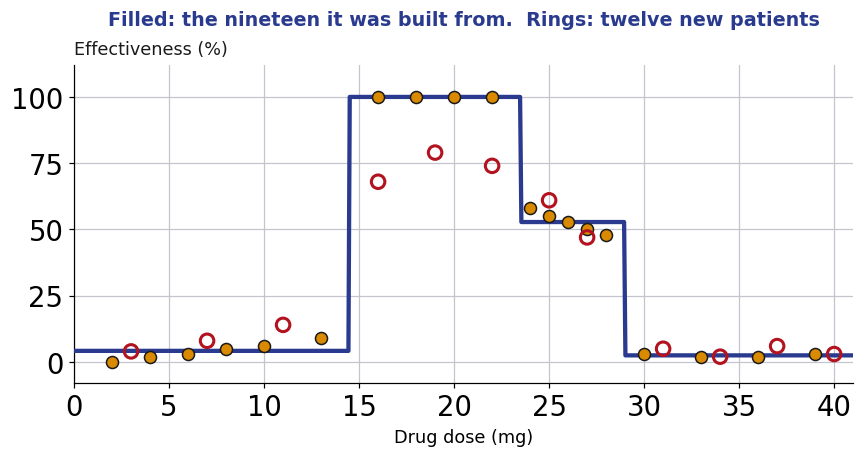

In [48]:
# a second wave of the same trial: twelve patients the tree has never seen
TD = np.array([3., 7., 11., 16., 19., 22., 25., 27., 31., 34., 37., 40.])
TE = np.array([4., 8., 14., 68., 79., 74., 61., 47., 5., 2., 6., 3.])

CUTS4 = [0, 14.5, 23.5, 29, 41]

def leaf_values(edges):
    """What each leaf predicts: the mean of the training patients in it."""
    return [EFF[(DOSE >= lo) & (DOSE < hi)].mean()
            for lo, hi in zip(edges[:-1], edges[1:])]

def predict(edges, x):
    out = np.empty_like(x, dtype=float)
    for (lo, hi), v in zip(zip(edges[:-1], edges[1:]), leaf_values(edges)):
        out[(x >= lo) & (x < hi)] = v
    return out

def step_curve(edges):
    g = np.linspace(0, 40.99, 600)
    return g, predict(edges, g)

def draw(ax, edges, rings=True, pale=None):
    ax.set_facecolor("white")
    ax.grid(True, color=chh.GRID, lw=0.8, zorder=0); ax.set_axisbelow(True)
    if pale is not None:
        g, s = step_curve(pale)
        ax.plot(g, s, lw=1.6, color=chh.GRID, zorder=2)
    g, s = step_curve(edges)
    ax.plot(g, s, lw=2.8, color=chh.MADRID, zorder=4)
    ax.scatter(DOSE, EFF, s=62, color=chh.ACCENT, edgecolors=chh.INK, lw=1.0,
               zorder=5)
    if rings:
        ax.scatter(TD, TE, s=78, facecolors="none", edgecolors=chh.FITLINE,
                   lw=2.0, zorder=6)
    ax.set_xlim(0, 41); ax.set_ylim(-8, 112)
    ax.set_xlabel("Drug dose (mg)", fontsize=11.5)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

fig, ax = plt.subplots(figsize=(8.2, 4.5), dpi=110)
fig.patch.set_facecolor("white")
draw(ax, CUTS4)
ax.text(0, 1.02, "Effectiveness (%)", transform=ax.transAxes, ha="left",
        va="bottom", fontsize=11.5, color=chh.INK)
ax.set_title("Filled: the nineteen it was built from.  Rings: twelve new patients",
             fontsize=12.5, color=chh.MADRID, weight="bold", pad=26)
fig.tight_layout()

### Their Residuals

- A residual is what the patient came in at minus what the leaf predicted
- Three leaves are close. The rings sit near the step and the lines are short
- The leaf that reads <b style="color:#73000A;">100%</b> is nowhere near its new patients

total on the new patients    2371.4
total on the old nineteen     116.6


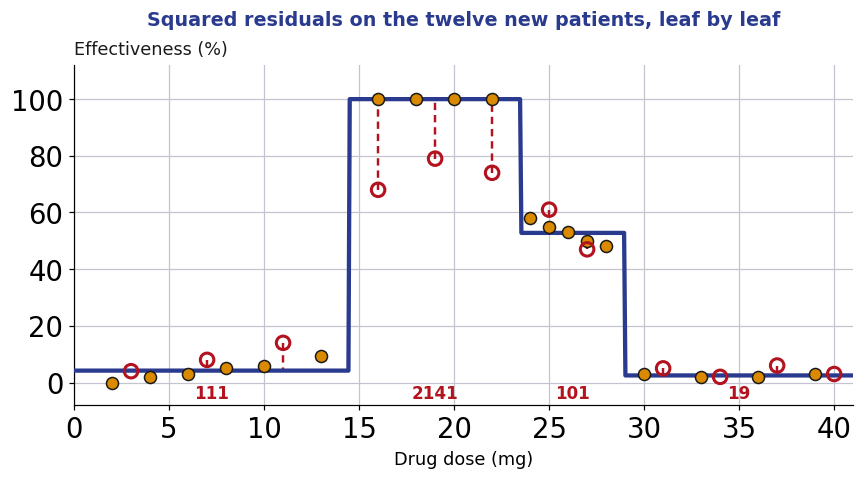

In [49]:
fig, ax = plt.subplots(figsize=(8.2, 4.7), dpi=110)
fig.patch.set_facecolor("white")
draw(ax, CUTS4)
for d, e in zip(TD, TE):
    ax.plot([d, d], [e, predict(CUTS4, np.array([d]))[0]], lw=1.6,
            color=chh.FITLINE, ls=(0, (3, 2)), zorder=3)
for lo, hi in zip(CUTS4[:-1], CUTS4[1:]):
    sel = (TD >= lo) & (TD < hi)
    ssr = ((TE[sel] - predict(CUTS4, TD[sel])) ** 2).sum()
    ax.text((lo + min(hi, 41)) / 2, -5.5, "%.0f" % ssr, ha="center",
            fontsize=11, color=chh.FITLINE, weight="bold")
ax.text(0, 1.02, "Effectiveness (%)", transform=ax.transAxes, ha="left",
        va="bottom", fontsize=11.5, color=chh.INK)
ax.set_title("Squared residuals on the twelve new patients, leaf by leaf",
             fontsize=12.5, color=chh.MADRID, weight="bold", pad=26)
fig.tight_layout()

print("total on the new patients  %8.1f" % ((TE - predict(CUTS4, TD)) ** 2).sum())
print("total on the old nineteen  %8.1f" % ((EFF - predict(CUTS4, DOSE)) ** 2).sum())

### The 100% Leaf Now Seems Like It Was Trained On Outliers

- <b style="color:#73000A;">2,141</b> of the <b style="color:#73000A;">2,371</b> comes from the leaf that reads 100%
- Four patients built that leaf, and all four came in at exactly 100
- The new patients in the same dose window average <b style="color:#73000A;">73.7</b>

### Remove Leaves
- One way to prevent overfitting is to remove some of the leaves
- Delete the <b style="color:#73000A;">Dose >= 23.5</b> question. Its two leaves become one, holding everyone from 14.5 to 29
- That leaf predicts <b style="color:#73000A;">73.8</b>, the average of nine patients instead of four
- Training SSR rises from 117 to <b style="color:#73000A;">5,067</b>. On the new patients it falls from 2,371 to <b style="color:#73000A;">1,071</b>

the merged leaf predicts 73.8, from 9 patients


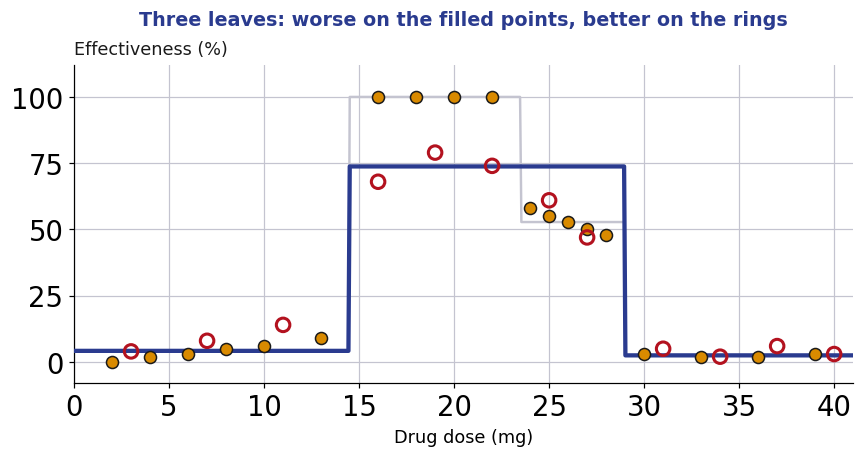

In [50]:
CUTS3 = [0, 14.5, 29, 41]

fig, ax = plt.subplots(figsize=(8.2, 4.5), dpi=110)
fig.patch.set_facecolor("white")
draw(ax, CUTS3, pale=CUTS4)
ax.text(0, 1.02, "Effectiveness (%)", transform=ax.transAxes, ha="left",
        va="bottom", fontsize=11.5, color=chh.INK)
ax.set_title("Three leaves: worse on the filled points, better on the rings",
             fontsize=12.5, color=chh.MADRID, weight="bold", pad=26)
fig.tight_layout()

print("the merged leaf predicts %.1f, from %d patients"
      % (EFF[(DOSE >= 14.5) & (DOSE < 29)].mean(),
         ((DOSE >= 14.5) & (DOSE < 29)).sum()))

### Or Keep Going

- Delete the <b style="color:#73000A;">Dose >= 29</b> question and you have two leaves. Delete the last one and you have a single leaf predicting 36.8 for everybody
- Training SSR only ever rises as you cut.

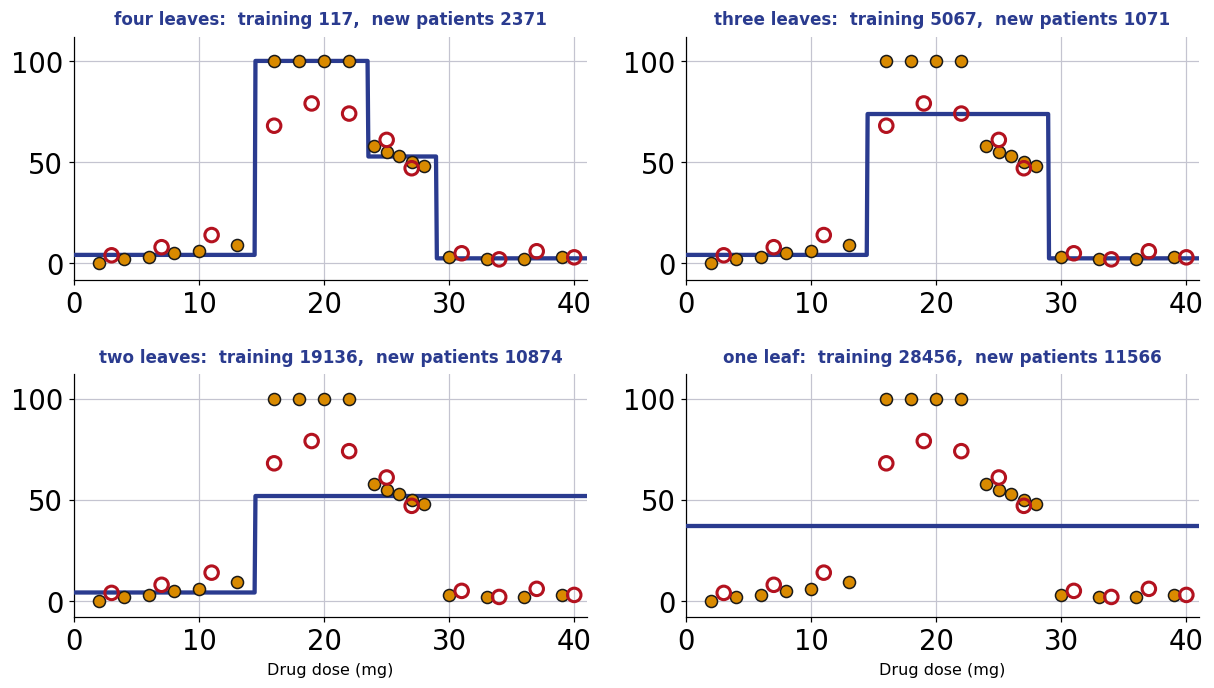

In [51]:
TREES = [("four leaves", [0, 14.5, 23.5, 29, 41]),
         ("three leaves", [0, 14.5, 29, 41]),
         ("two leaves", [0, 14.5, 41]),
         ("one leaf", [0, 41])]

fig, axes = plt.subplots(2, 2, figsize=(11.4, 6.6), dpi=110)
fig.patch.set_facecolor("white")
for ax, (name, edges) in zip(axes.ravel(), TREES):
    draw(ax, edges)
    ax.set_title("%s:  training %.0f,  new patients %.0f"
                 % (name, ((EFF - predict(edges, DOSE)) ** 2).sum(),
                    ((TE - predict(edges, TD)) ** 2).sum()),
                 fontsize=11, color=chh.MADRID, weight="bold", pad=8)
    ax.set_xlabel("")
for ax in axes[1]:
    ax.set_xlabel("Drug dose (mg)", fontsize=10.5)
fig.tight_layout()

## Three Ways to Keep a Tree Small

- <b style="color:#73000A;">max_depth</b>: cap how many questions deep it can go. Depth 1 is one split and two leaves
- <b style="color:#73000A;">min_samples_leaf</b>: refuse any split that would leave a leaf below that many rows
- <b style="color:#73000A;">ccp_alpha</b>: let it grow all the way, then cut leaves back by tree score, SSR plus a price per leaf
- The first two stop it early and are cheap. The third has to grow the tree first, and earns its cost when the one tree is what you are presenting
- In the end, we won't need to prune for our purposes though... (see next lecture)

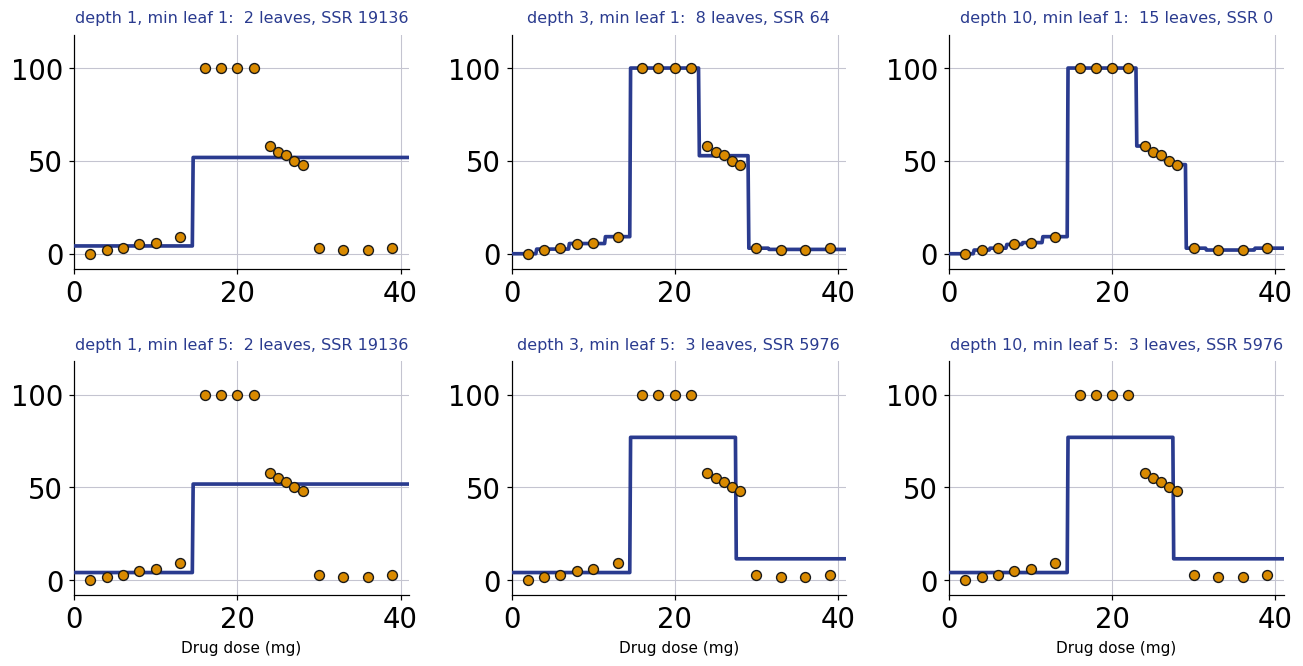

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(12.2, 6.4), dpi=110)
fig.patch.set_facecolor("white")
at = np.linspace(0, 41, 400).reshape(-1, 1)

for row, leaf_min in enumerate((1, 5)):
    for col, depth in enumerate((1, 3, 10)):
        ax = axes[row, col]
        ax.set_facecolor("white")
        t = DecisionTreeRegressor(max_depth=depth, min_samples_leaf=leaf_min,
                                  random_state=0).fit(DOSE.reshape(-1, 1), EFF)
        ax.grid(True, color=chh.GRID, lw=0.7, zorder=0); ax.set_axisbelow(True)
        ax.plot(at.ravel(), t.predict(at), lw=2.4, color=chh.MADRID, zorder=4)
        ax.scatter(DOSE, EFF, s=42, color=chh.ACCENT, edgecolors=chh.INK,
                   lw=0.9, zorder=5)
        ax.set_xlim(0, 41); ax.set_ylim(-8, 118)
        ax.set_title("depth %d, min leaf %d:  %d leaves, SSR %.0f"
                     % (depth, leaf_min, t.get_n_leaves(),
                        ((t.predict(DOSE.reshape(-1, 1)) - EFF) ** 2).sum()),
                     fontsize=10.5, color=chh.MADRID, pad=8)
        if row == 1:
            ax.set_xlabel("Drug dose (mg)", fontsize=10)
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)
fig.tight_layout()

### So Which Tree??

**Cost Complexity Pruning**

$$\text{tree score} \;=\; \text{SSR} \;+\; \alpha \times (\text{number of leaves})$$

- A leaf earns its keep by lowering SSR. One that does not gets cut
- Similar to ridge and lasso: fit, plus a penalty on complexity

### Score Every Tree at One Price

Say we are given alpha to be <b style="color:#73000A;">10,000</b>

In [53]:
def train_ssr(edges):
    return ((EFF - predict(edges, DOSE)) ** 2).sum()

def tree_score(edges, alpha):
    return train_ssr(edges) + alpha * (len(edges) - 1)

for alpha in (10000,):
    print("a leaf costs %d" % alpha)
    print("   %-13s %10s   %8s   %12s" % ("", "SSR", "leaves", "tree score"))
    for name, edges in TREES:
        k = len(edges) - 1
        print("   %-13s %10.1f + %d x %d = %12.1f"
              % (name, train_ssr(edges), alpha, k, tree_score(edges, alpha)))
    win = min(TREES, key=lambda t: tree_score(t[1], alpha))
    print("   lowest score: %s" % win[0])

a leaf costs 10000
                        SSR     leaves     tree score
   four leaves        116.6 + 10000 x 4 =      40116.6
   three leaves      5067.4 + 10000 x 3 =      35067.4
   two leaves       19136.5 + 10000 x 2 =      39136.5
   one leaf         28456.1 + 10000 x 1 =      38456.1
   lowest score: three leaves


### Change the Price, Change the Tree

At alpha <b style="color:#73000A;">22,000</b> a leaf is expensive enough that one leaf beats everything.

In [54]:
for alpha in (22000,):
    print("a leaf costs %d" % alpha)
    for name, edges in TREES:
        print("   %-13s %12.1f" % (name, tree_score(edges, alpha)))
    print("   lowest score: %s"
          % min(TREES, key=lambda t: tree_score(t[1], alpha))[0])

a leaf costs 22000
   four leaves        88116.6
   three leaves       71067.4
   two leaves         63136.5
   one leaf           50456.1
   lowest score: one leaf


## So how do we choose $\alpha$?

### Step 1: Raise Alpha and Collect the Trees

On <b style="color:#73000A;">all</b> the data, grow the full tree, then raise alpha and write down
every tree that wins somewhere.

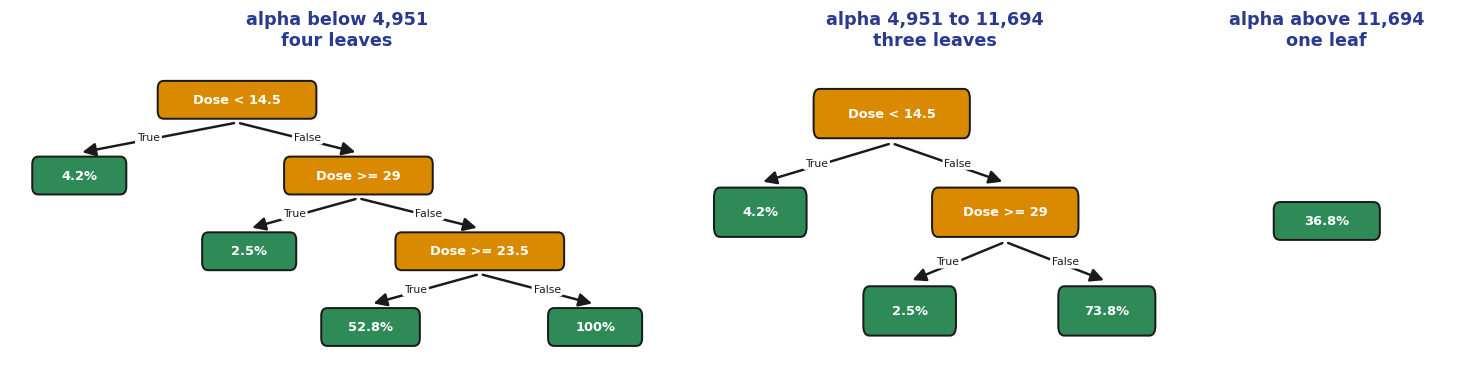

In [55]:
T4 = ({"root": (0.0, 2.6, "Dose < 14.5", "q"),
       "l":    (-2.6, 1.6, "4.2%", "leaf"),
       "r":    (2.0, 1.6, "Dose >= 29", "q"),
       "rl":   (0.2, 0.6, "2.5%", "leaf"),
       "rr":   (4.0, 0.6, "Dose >= 23.5", "q"),
       "rrl":  (2.2, -0.4, "52.8%", "leaf"),
       "rrr":  (5.9, -0.4, "100%", "leaf")},
      [("root", "l", "True"), ("root", "r", "False"),
       ("r", "rl", "True"), ("r", "rr", "False"),
       ("rr", "rrl", "True"), ("rr", "rrr", "False")])

T3 = ({"root": (0.0, 2.0, "Dose < 14.5", "q"),
       "l":    (-2.2, 1.0, "4.2%", "leaf"),
       "r":    (1.9, 1.0, "Dose >= 29", "q"),
       "rl":   (0.3, 0.0, "2.5%", "leaf"),
       "rr":   (3.6, 0.0, "73.8%", "leaf")},
      [("root", "l", "True"), ("root", "r", "False"),
       ("r", "rl", "True"), ("r", "rr", "False")])

T1 = ({"only": (0.0, 1.0, "36.8%", "leaf")}, [])

fig, axes = plt.subplots(1, 3, figsize=(13.6, 3.9), dpi=110,
                         gridspec_kw=dict(width_ratios=[1.35, 1.0, 0.5]))
fig.patch.set_facecolor("white")
for ax, (nodes, edges), head in zip(
        axes, (T4, T3, T1),
        ("alpha below 4,951\nfour leaves",
         "alpha 4,951 to 11,694\nthree leaves",
         "alpha above 11,694\none leaf")):
    draw_tree(nodes, edges, ax=ax, fs=8.5)
    ax.set_title(head, fontsize=11.5, color=chh.MADRID, weight="bold", pad=6)
# one box would otherwise fill its panel, so borrow the first panel's scale
axes[2].set_xlim(-1.85, 1.85)
axes[2].set_ylim(*axes[0].get_ylim())
fig.tight_layout()

### Step 2: Hold Patients Back and Score Each One

Build the short list without the held back patients, then ask the held back
patients which tree they prefer.

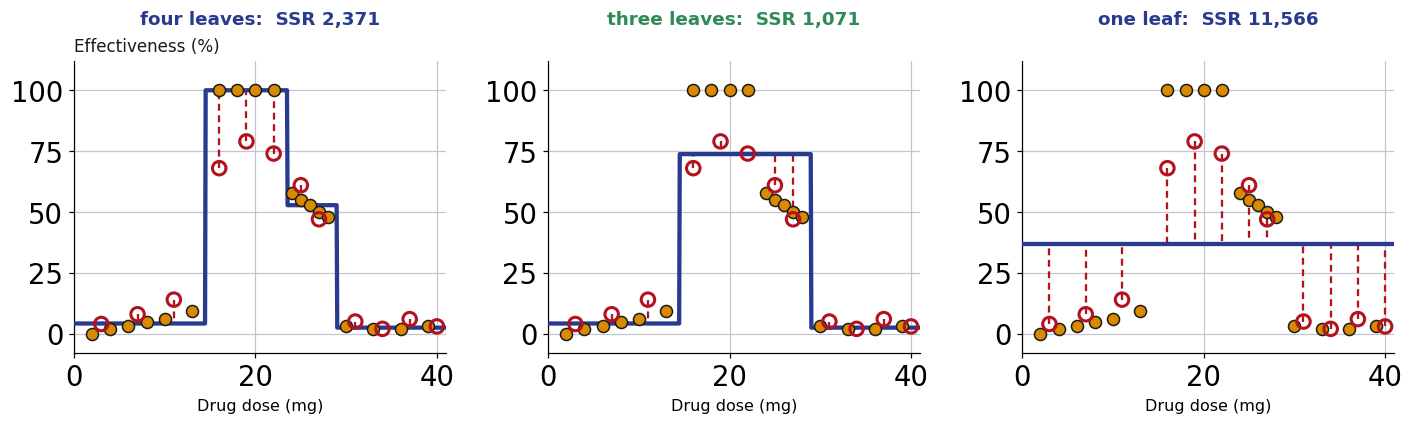

In [56]:
SHORT = [("four leaves", [0, 14.5, 23.5, 29, 41]),
         ("three leaves", [0, 14.5, 29, 41]),
         ("one leaf", [0, 41])]
best = min(SHORT, key=lambda t: ((TE - predict(t[1], TD)) ** 2).sum())[0]

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2), dpi=110)
fig.patch.set_facecolor("white")
for ax, (name, edges) in zip(axes, SHORT):
    draw(ax, edges)
    for d, e in zip(TD, TE):
        ax.plot([d, d], [e, predict(edges, np.array([d]))[0]], lw=1.5,
                color=chh.FITLINE, ls=(0, (3, 2)), zorder=3)
    ax.set_title("{}:  SSR {:,.0f}".format(
                     name, ((TE - predict(edges, TD)) ** 2).sum()),
                 fontsize=12, weight="bold", pad=24,
                 color="#2E8B57" if name == best else chh.MADRID)
    ax.set_xlabel("Drug dose (mg)", fontsize=10.5)
axes[0].text(0, 1.02, "Effectiveness (%)", transform=axes[0].transAxes,
             ha="left", va="bottom", fontsize=11, color=chh.INK)
fig.tight_layout()

### Step 3: Do That Ten Times

Hold back a different tenth each time, score the short list each time, and
average the ten scores for each alpha.

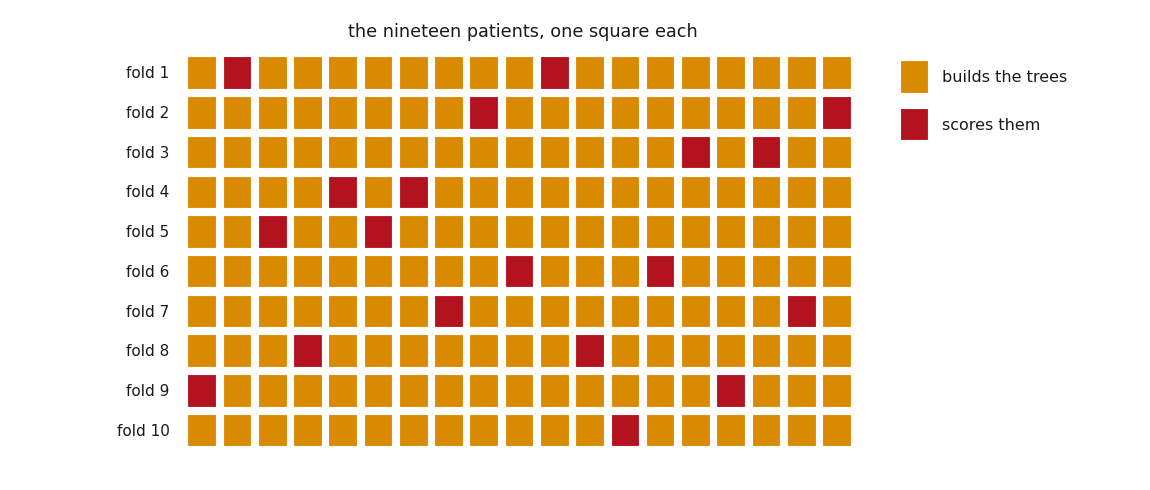

In [57]:
from sklearn.model_selection import KFold

folds = KFold(n_splits=10, shuffle=True, random_state=0)

fig, ax = plt.subplots(figsize=(10.8, 4.8), dpi=110)
fig.patch.set_facecolor("white"); ax.set_facecolor("white")
for r, (build, hold) in enumerate(folds.split(DOSE)):
    for j in range(len(DOSE)):
        ax.add_patch(plt.Rectangle((j, -r), 0.84, 0.84, lw=1.4,
                                   facecolor=chh.FITLINE if j in hold else chh.ACCENT,
                                   edgecolor="white"))
    ax.text(-0.5, -r + 0.42, "fold %d" % (r + 1), ha="right", va="center",
            fontsize=10, color=chh.INK)
ax.text(9.5, 1.35, "the nineteen patients, one square each", ha="center",
        fontsize=11.5, color=chh.INK)
ax.add_patch(plt.Rectangle((20.2, -0.1), 0.84, 0.84, facecolor=chh.ACCENT,
                           edgecolor="white", lw=1.4))
ax.text(21.4, 0.32, "builds the trees", va="center", fontsize=10.5, color=chh.INK)
ax.add_patch(plt.Rectangle((20.2, -1.3), 0.84, 0.84, facecolor=chh.FITLINE,
                           edgecolor="white", lw=1.4))
ax.text(21.4, -0.88, "scores them", va="center", fontsize=10.5, color=chh.INK)
ax.set_xlim(-5.0, 27.0); ax.set_ylim(-9.8, 2.0)
ax.axis("off")
fig.tight_layout()

### Step 4: Take the Winner, Refit on Everything

Go back to the trees from step 1, take the one that alpha chose, and fit it on
every patient you have.

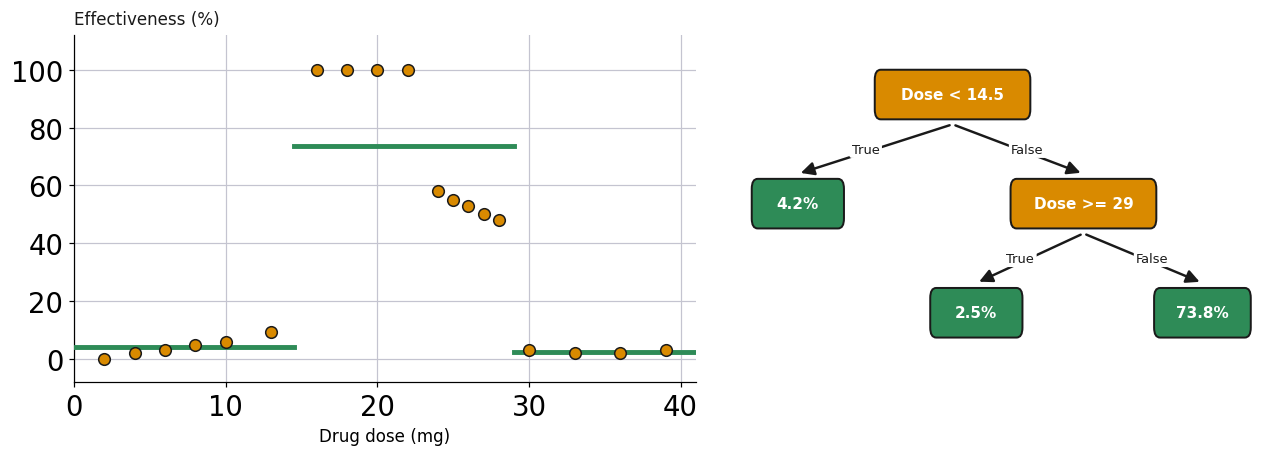

In [58]:
nodes = {
    "root": (0.0, 2.6, "Dose < 14.5", "q"),
    "l":    (-2.6, 1.5, "4.2%", "leaf"),
    "r":    (2.2, 1.5, "Dose >= 29", "q"),
    "rl":   (0.4, 0.4, "2.5%", "leaf"),
    "rr":   (4.2, 0.4, "73.8%", "leaf"),
}
edges = [("root", "l", "True"), ("root", "r", "False"),
         ("r", "rl", "True"), ("r", "rr", "False")]
display(pair(nodes, edges, leaves=[(0, 14.5), (14.5, 29), (29, 41)]))

### The Four Steps

1. On <b style="color:#73000A;">all</b> the data, grow the full tree and raise alpha. Keep every tree that wins somewhere
2. Hold some patients back. Build that short list without them, and score each tree on the ones you held back
3. Do step 2 ten times, holding back a different tenth each time. Average the ten scores for each alpha
4. Take the alpha with the lowest average, and use its tree from step 1, fit on everything

### In scikit-learn

- Three lines: make the estimator, <b style="color:#73000A;">fit</b> it, <b style="color:#73000A;">predict</b> from it
- X is a column of doses and y a column of outcomes. No formula, no design matrix, no dummies to write
- <b style="color:#73000A;">DecisionTreeClassifier</b> is the same class for the classification side, scored by Gini instead of SSR

In [60]:
from sklearn.tree import DecisionTreeRegressor

# min_samples_split=7: a node must hold at least 7 people before the
# tree may ask another question. This is the brake that stops it from
# splitting all the way down to one person per leaf.
model = DecisionTreeRegressor(min_samples_split=7)

# sklearn expects X as a 2D array (rows = observations, columns = features).
# We have one feature, so reshape(-1, 1) turns the flat dose vector
# into a one-column matrix.
model.fit(DOSE.reshape(-1, 1), EFF)

# The fitted tree stores every node in model.tree_. Internal nodes
# (the ones that ask a question) have feature >= 0; leaves are coded -2.
inner = model.tree_.feature >= 0

# threshold[inner]: the cutoffs the tree chose, i.e. its questions.
print("questions it chose:      "
      + ",   ".join("dose < %.1f" % t for t in sorted(model.tree_.threshold[inner])))

# value[~inner]: the number each leaf predicts -- just the mean
# outcome of the training observations that landed in that leaf.
print("numbers in its leaves:   "
      + ",   ".join("%.1f" % v for v in model.tree_.value[~inner].ravel()))

print()
print("%8s %14s" % ("dose", "prediction"))
print("%8s %14s" % ("-" * 6, "-" * 12))

# Predicting is just playing 20 questions: each dose gets routed down
# the tree until it hits a leaf, and the leaf's mean is the answer.
# Note every dose in the same leaf gets the identical prediction --
# that's why tree predictions are step functions, not smooth curves.
for d in (5, 18, 26, 35):
    print("%8d %13.1f%%" % (d, model.predict([[d]])[0]))

questions it chose:      dose < 14.5,   dose < 23.0,   dose < 29.0
numbers in its leaves:   4.2,   100.0,   52.8,   2.5

    dose     prediction
  ------   ------------
       5           4.2%
      18         100.0%
      26          52.8%
      35           2.5%


## Key Ideas

- A tree is a sequence of true or false questions ending in a <b style="color:#73000A;">leaf</b>
- <b style="color:#73000A;">Classification</b>: choose splits that minimize weighted <b style="color:#73000A;">Gini impurity</b>
- <b style="color:#73000A;">Regression</b>: choose splits that minimize <b style="color:#73000A;">SSR</b>; leaves predict the mean
- Predictions are <b style="color:#73000A;">piecewise constant</b>, so trees cannot extrapolate
- Trees <b style="color:#73000A;">overfit</b> unless you cap the depth, hold leaves above a size, or <b style="color:#73000A;">prune</b> back by tree score
- A column that never wins a split is simply <b style="color:#73000A;">absent</b> from the model, and a missing value has a side to go down